# Tarea 01: Aproximación de una función desconocida

**Clave:** 208999 · **Variante:** `v2e419aae`

Se aproxima la relación entre doce variables y una respuesta a partir de 800
observaciones. El modelo se compara con una regresión sobre las variables originales
y con una expansión polinomial regularizada. Al final se generan las predicciones
para las 400 observaciones de prueba.

[Enunciado del curso](https://github.com/nasaul/mineria_datos/blob/213958e9aaeea54988478056defd3d07b4db3da1/tareas/tarea_01_aproximacion_funcion.ipynb).


El modelo final combina siete términos: un efecto lineal, un cuadrado, un seno,
un logaritmo, un cubo, un cambio de nivel y una interacción. Sus coeficientes se
estiman juntos por mínimos cuadrados. Las siguientes secciones presentan las
gráficas, las alternativas probadas y la comparación de errores.


In [1]:
import hashlib
import json
import platform
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from PIL import Image
from scipy import stats
import sklearn
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from threadpoolctl import threadpool_limits

threadpool_limits(limits=1)
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})
SEMILLA = 42
CLAVE_UNICA = "208999"

# Detener el ajuste si Lasso no converge.
warnings.filterwarnings("error", category=ConvergenceWarning)


## Parte 0. Datos y método de evaluación

La partición usa la semilla 42: 600 observaciones para desarrollar el modelo y
200 para validación. Los candidatos se comparan dentro de las 600 observaciones
mediante validación cruzada de cinco pliegues, repetida cuatro veces. Todos usan
las mismas particiones.

La CV también interviene en la selección de términos, por lo que su error puede
ser optimista. La evaluación final utiliza las mismas 200 observaciones de
validación en todas las comparaciones. `test.csv` se utiliza al generar la entrega.


In [2]:
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "tareas/tarea_01_datos").is_dir())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA
RESULTADOS = RAIZ / "tareas/resultados_208999"
RESULTADOS.mkdir(parents=True, exist_ok=True)
VARIABLES = [f"x{i}" for i in range(1, 13)]

train = pd.read_csv(MIS_DATOS / "train.csv")
assert CARPETA == "v2e419aae"
assert train.shape == (800, 13)
assert list(train.columns) == VARIABLES + ["y"]
assert np.isfinite(train.to_numpy()).all()
desarrollo, validacion = train_test_split(train, test_size=0.25, random_state=SEMILLA)
X_train, y_train = desarrollo[VARIABLES], desarrollo["y"]
X_val, y_val = validacion[VARIABLES], validacion["y"]
assert set(desarrollo.index).isdisjoint(validacion.index)
assert set(desarrollo.index) | set(validacion.index) == set(train.index)
PLIEGUES = list(RepeatedKFold(n_splits=5, n_repeats=4, random_state=137).split(X_train))
print(f"Variante: {CARPETA} | Desarrollo: {len(desarrollo)} | Validación: {len(validacion)}")
display(desarrollo.describe().T)
print(f"Faltantes en train: {train.isna().sum().sum()}")

Variante: v2e419aae | Desarrollo: 600 | Validación: 200


,count,mean,std,min,25%,50%,75%,max
x1,600.0000,0.0155,0.2839,-0.4994,-0.2191,0.0273,0.2626,0.4996
x2,600.0000,0.0199,1.1475,-1.9898,-0.9584,-0.0182,1.0614,1.9998
x3,600.0000,1.7539,2.3991,0.0248,0.4441,0.9840,2.0533,21.4247
x4,600.0000,1.9881,1.1734,0.0029,1.0058,1.9526,3.0034,3.9907
x5,600.0000,0.0037,1.0773,-3.1518,-0.7814,-0.0682,0.7882,3.1494
x6,600.0000,1.8079,2.7542,0.0495,0.5123,0.9505,1.9555,32.2331
x7,600.0000,0.1038,1.1318,-1.9934,-0.8867,0.1410,1.1084,1.9984
x8,600.0000,0.0093,0.2798,-0.4989,-0.2058,-0.0026,0.2533,0.4987
x9,600.0000,50.4167,28.5995,0.0541,26.4866,51.4943,75.2043,99.9340
x10,600.0000,0.0121,1.7685,-2.9973,-1.4737,-0.0196,1.5983,2.9954


Faltantes en train: 0


In [3]:
def evaluar_cv(matriz):
    """MSE OLS en desarrollo con los mismos 20 pliegues para cada candidato."""
    errores = -cross_val_score(
        LinearRegression(), matriz, y_train, cv=PLIEGUES,
        scoring="neg_mean_squared_error", n_jobs=1, error_score="raise",
    )
    return {"MSE_CV": float(errores.mean()), "DE_pliegues": float(errores.std(ddof=1)),
            "columnas": matriz.shape[1]}


TITULOS_FIGURAS = {
    "01_distribuciones.png": "Distribuciones de las 12 variables",
    "02_respuesta.png": "Respuesta observada frente a cada variable",
    "03_correlacion.png": "Correlaciones de Pearson",
    "04_residuales_baseline.png": "Punto de partida: regresión con las 12 variables crudas",
    "05_residuales_aditivo.png": "Modelo aditivo: cinco transformaciones y 12 variables crudas",
    "06_interaccion.png": "Interacción: la pendiente de x11 cambia con x1",
    "07_residuales_validacion.png": "Modelo compacto: residuales en la validación",
    "08_validacion.png": "Predicciones y diagnóstico del modelo compacto",
    "09_comparacion_lasso.png": "Modelo guiado frente a polinomios y LassoCV",
    "hipotesis_exponencial.png": "Hipótesis descartada: exponencial frente a cuadrado",
    "residuales_compacto.png": "Modelo compacto: detalle de los residuales",
    "residuales_paso_01.png": "Paso 1: agregar x2²",
    "residuales_paso_02.png": "Paso 2: agregar sin(2π x4)",
    "residuales_paso_03.png": "Paso 3: agregar log(x6)",
    "residuales_paso_04.png": "Paso 4: agregar x7³",
    "residuales_paso_05.png": "Paso 5: agregar el escalón en x9 > 60",
    "residuales_paso_06.png": "Paso 6: agregar la interacción x1 × x11",
}


def guardar_figura(nombre, titulo=None, nota="", leyenda=False):
    fig = plt.gcf()
    alto = fig.get_figheight()
    fig.text(0.5, 1 - 0.12 / alto, titulo or TITULOS_FIGURAS.get(nombre, nombre),
             ha="center", va="top", fontsize=15, fontweight="bold")
    es_validacion = nombre.startswith(("07_", "08_"))
    muestra = "Validación: 200 observaciones; entrenamiento: 600" if es_validacion else "Desarrollo: 600 filas"
    fig.text(0.5, 1 - 0.47 / alto, muestra, ha="center", va="top", fontsize=10)
    if leyenda:
        fig.legend(handles=[
            Line2D([], [], linestyle="", marker="o", color="#0072B2", alpha=0.5, label="Observación"),
            Line2D([], [], color="#D55E00", marker="o", markersize=3, label="Media por grupo ± 1 EE"),
        ], loc="lower center", bbox_to_anchor=(0.5, 0.40 / alto), ncol=2, frameon=False, fontsize=9)
    if nota:
        fig.text(0.02, 0.06 / alto, nota, fontsize=8, va="bottom")
    fig.tight_layout(rect=(0, (0.90 if leyenda else 0.60) / alto, 1, 1 - 0.85 / alto),
                     pad=0.9, h_pad=1.4, w_pad=1.2)
    fig.savefig(RESULTADOS / nombre, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)


def tendencia_por_grupos(ax, x, respuesta, grupos=12):
    datos = pd.DataFrame({"x": np.asarray(x), "y": np.asarray(respuesta)})
    resumen = datos.groupby(pd.qcut(datos["x"], q=grupos, duplicates="drop"), observed=True).agg(
        x=("x", "mean"), media=("y", "mean"), sd=("y", "std"), n=("y", "size"))
    ax.errorbar(resumen["x"], resumen["media"], yerr=resumen["sd"] / np.sqrt(resumen["n"]),
                fmt="o-", markersize=3, color="#D55E00", linewidth=1.5, capsize=2)
    return resumen


cv_baseline = evaluar_cv(X_train)
print(f"Baseline de 12 variables crudas: MSE CV = {cv_baseline['MSE_CV']:.4f}")

Baseline de 12 variables crudas: MSE CV = 104.6655


## Parte 1. Exploración

Las distribuciones muestran escalas distintas y colas a la derecha en `x3` y `x6`.
La correlación por sí sola no me alcanza para descartar una variable. También
reviso las formas de las dispersiones, porque una relación curva puede tener
poca correlación lineal.


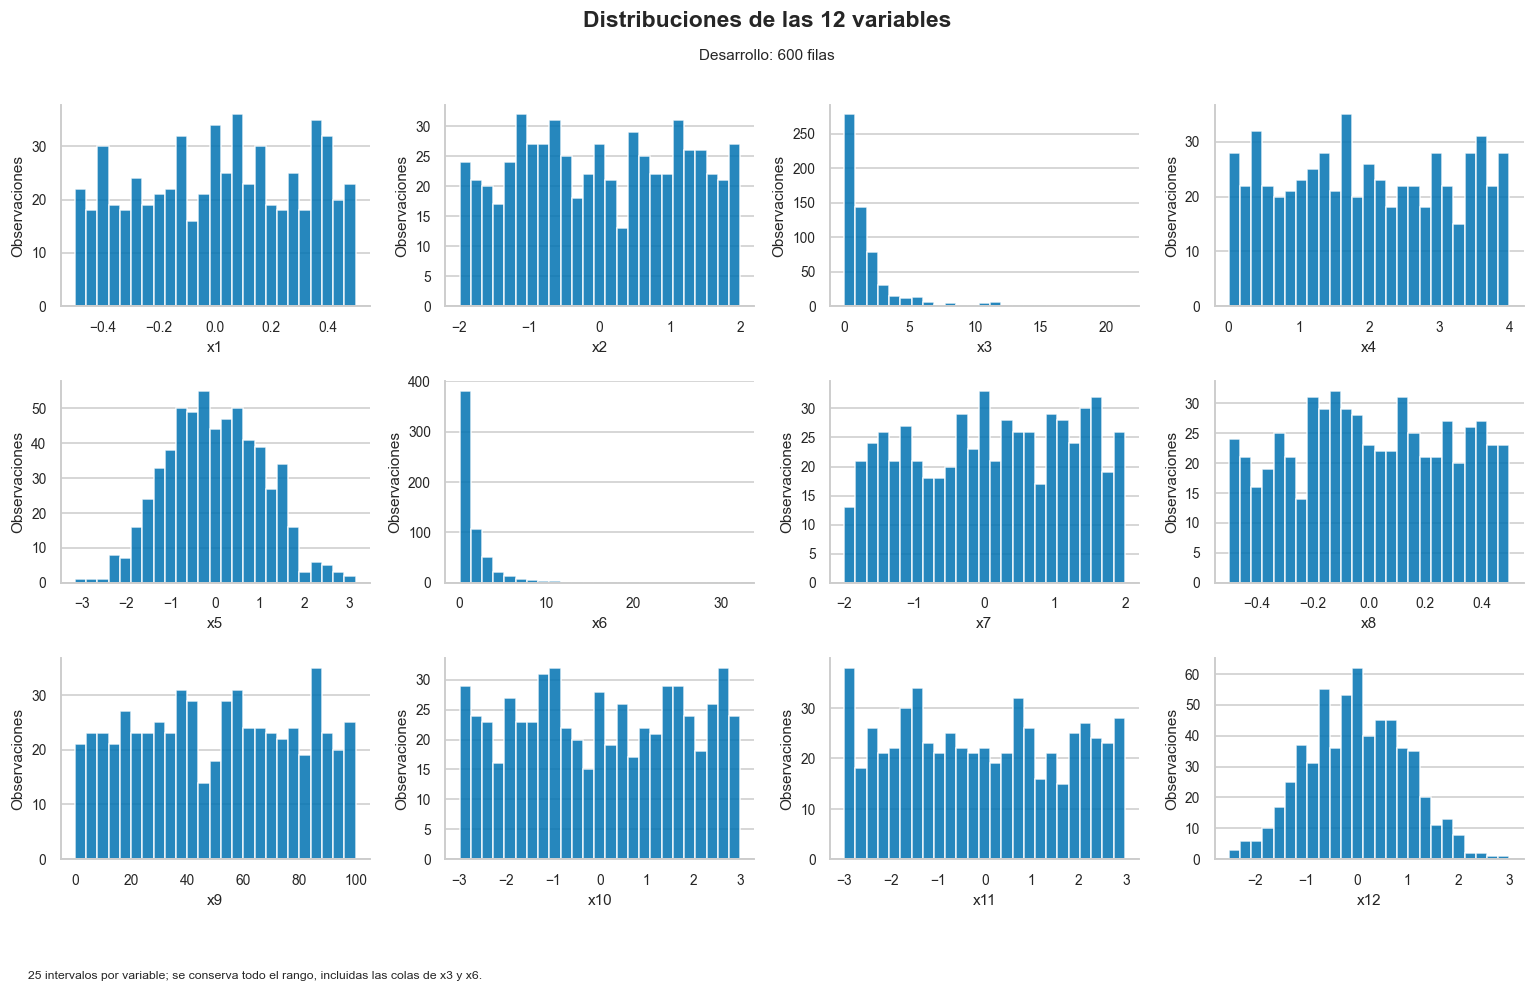

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for variable, ax in zip(VARIABLES, axes.flat):
    ax.hist(X_train[variable], bins=25, color="#0072B2", alpha=0.85)
    ax.set(xlabel=variable, ylabel="Observaciones")
    ax.grid(axis="x", visible=False)
guardar_figura("01_distribuciones.png", nota="25 intervalos por variable; se conserva todo el rango, incluidas las colas de x3 y x6.")

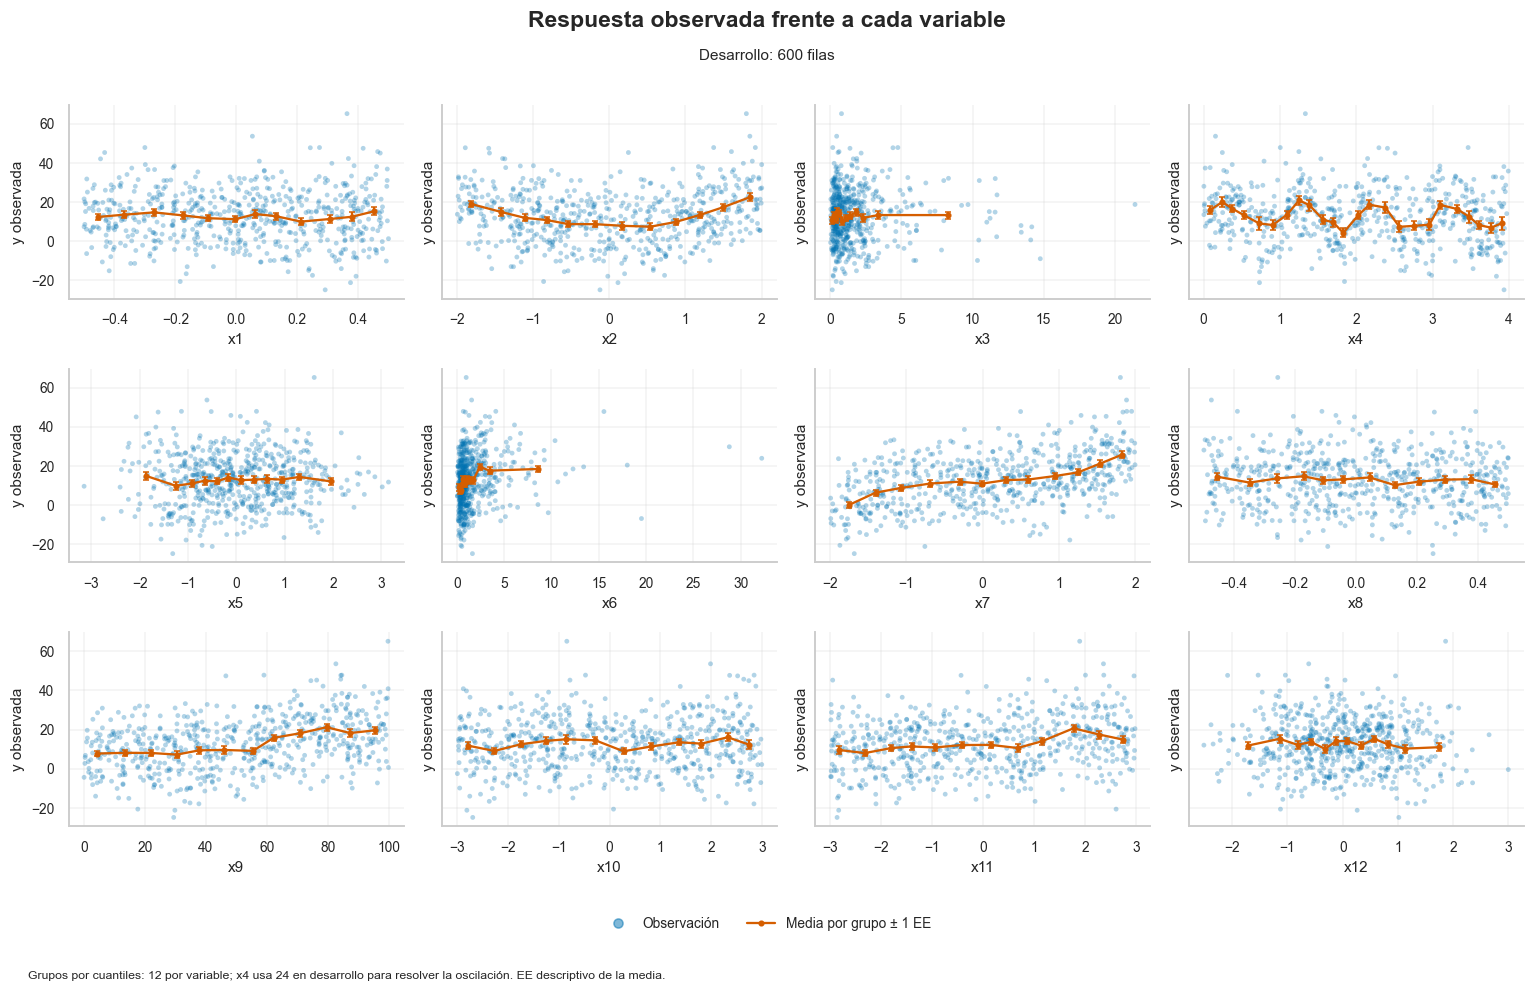

In [5]:
def paneles_respuesta(datos, respuesta, titulo, nombre):
    fig, axes = plt.subplots(3, 4, figsize=(14, 9), sharey=True)
    es_residual = "Residual" in titulo
    misma_escala = nombre.startswith("residuales_paso_") or nombre.startswith(("04_", "05_"))
    if es_residual:
        limite = LIMITE_ESCALERA if misma_escala else 5 * np.ceil(np.max(np.abs(respuesta)) / 5)
    for variable, ax in zip(VARIABLES, axes.flat):
        ax.scatter(datos[variable], respuesta, s=10, alpha=0.30, color="#0072B2", edgecolors="none")
        tendencia_por_grupos(ax, datos[variable], respuesta,
                             grupos=24 if variable == "x4" and len(datos) >= 500 else 12)
        if es_residual:
            ax.axhline(0, color="#444444", linewidth=0.9, linestyle="--")
            ax.set_ylim(-limite, limite)
        ax.set(xlabel=variable, ylabel=titulo)
        ax.grid(alpha=0.25)
    nota = "Grupos por cuantiles: 12 por variable; x4 usa 24 en desarrollo para resolver la oscilación. EE descriptivo de la media."
    if es_residual:
        nota += "\n" + ("Escala vertical fija en toda la escalera." if misma_escala else "Escala ampliada para inspeccionar el patrón restante.")
        if not nombre.startswith("07_"):
            nota += " Residuales calculados fuera del pliegue de entrenamiento."
    guardar_figura(nombre, nota=nota, leyenda=True)


paneles_respuesta(X_train, y_train, "y observada", "02_respuesta.png")

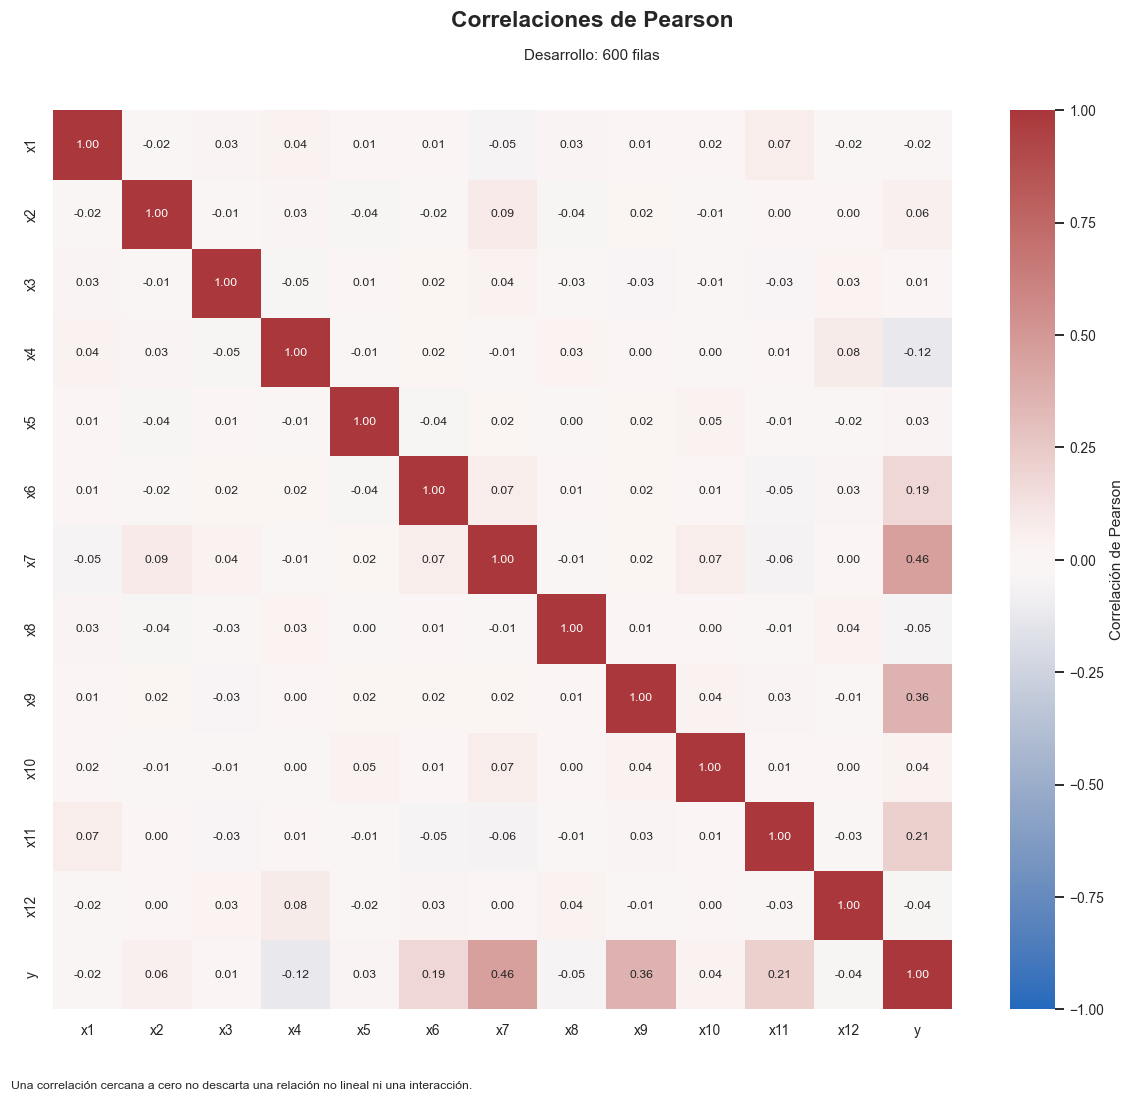

In [6]:
fig, ax = plt.subplots(figsize=(11, 10))
correlaciones = desarrollo.corr()
etiquetas = correlaciones.map(lambda r: "0.00" if abs(r) < 0.005 else f"{r:.2f}")
sns.heatmap(correlaciones, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax,
            annot=etiquetas, fmt="", annot_kws={"size": 8}, square=True,
            cbar_kws={"label": "Correlación de Pearson"})
guardar_figura("03_correlacion.png", nota="Una correlación cercana a cero no descarta una relación no lineal ni una interacción.")

### 1.1 Lectura de las gráficas

| Variable | Interpretación | Gráfica | Certeza |
|---|---|---|---|
| x1 | Efecto marginal débil; puede participar en una interacción | Dispersión y correlación | Baja |
| x2 | Curvatura aproximadamente cuadrática | Residuales del baseline | Alta |
| x3 | Asimetría positiva; relación con y poco clara | Histograma y dispersión | Baja |
| x4 | Oscilación que una recta no representa | Dispersión y residuales | Media |
| x5 | Relación marginal poco clara | Dispersión y correlación | Baja |
| x6 | Cola derecha y relación compatible con un logaritmo | Histograma y residuales | Media |
| x7 | Tendencia creciente con curvatura | Dispersión y residuales | Alta |
| x8 | Relación marginal poco clara | Dispersión y correlación | Baja |
| x9 | Posible cambio de nivel | Dispersión y residuales del modelo aditivo | Media |
| x10 | Relación marginal poco clara | Dispersión y correlación | Baja |
| x11 | Efecto lineal y posible interacción | Correlación y dispersión por pares | Media |
| x12 | Relación marginal poco clara | Dispersión y correlación | Baja |


## Parte 2. Escalera de residuales

El residual es la diferencia entre la respuesta y su predicción: $e_i=y_i-\widehat y_i$.
Cada punto de estas gráficas usa una predicción del primer ciclo de CV, obtenida
sin incluir esa observación en el ajuste.

Se parte de las doce variables originales y se agregan sucesivamente `x2²`,
`sin(2π*x4)`, `log(x6)`, `x7³` y `1(x9>60)`. Estos términos representan, respectivamente,
la curvatura en `x2`, la oscilación en `x4`, el crecimiento decreciente en `x6`,
la curvatura cúbica en `x7` y el salto de nivel en `x9`.

Los doce paneles se conservan después de cada paso con la misma escala vertical.
Así se puede comparar la estructura que desaparece y la reducción del error,
sin confundir una menor dispersión con un cambio de escala.


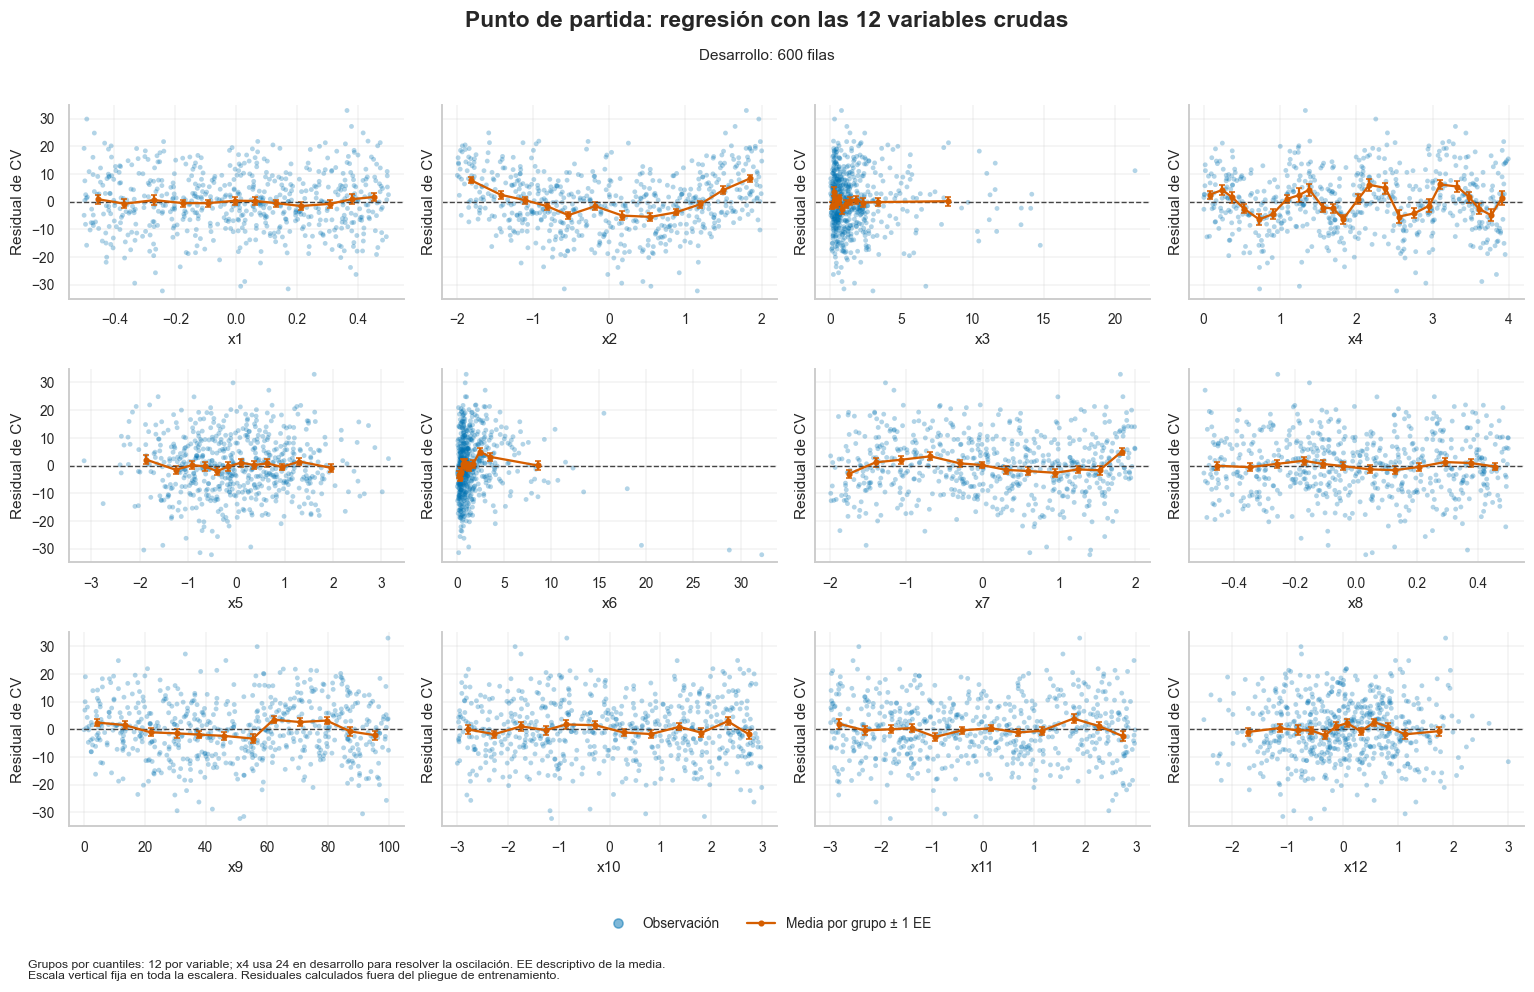

In [7]:
TERMINOS = {
    "x2_cuadrado": lambda d: d["x2"] ** 2,
    "seno_x4": lambda d: np.sin(2 * np.pi * d["x4"]),
    "log_x6": lambda d: np.log(d["x6"]),
    "x7_cubo": lambda d: d["x7"] ** 3,
    "escalon_x9": lambda d: (d["x9"] > 60).astype(float),
    "interaccion_x1_x11": lambda d: d["x1"] * d["x11"],
}


def construir(datos, nombres=(), crudas=True):
    """Construye las variables originales o compactas y los términos indicados."""
    salida = datos[VARIABLES].copy() if crudas else datos[["x11"]].copy()
    if "log_x6" in nombres and (datos["x6"] <= 0).any():
        raise ValueError("log(x6) requiere valores positivos.")
    for nombre in nombres:
        salida[nombre] = TERMINOS[nombre](datos)
    if not np.isfinite(salida.to_numpy()).all():
        raise ValueError("La matriz contiene valores no finitos.")
    return salida


def residuales_cv(matriz):
    pred = cross_val_predict(LinearRegression(), matriz, y_train, cv=PLIEGUES[:5])
    return y_train.to_numpy() - pred


residuales_baseline = residuales_cv(X_train)
LIMITE_ESCALERA = 5 * np.ceil(np.max(np.abs(residuales_baseline)) / 5)
paneles_respuesta(X_train, residuales_baseline, "Residual de CV", "04_residuales_baseline.png")

### 2.1 Cuadrado de x2

Con `x2²`, el MSE CV baja de 104.67 a 83.34. El cuadrado permite representar la curvatura que queda con la variable original.

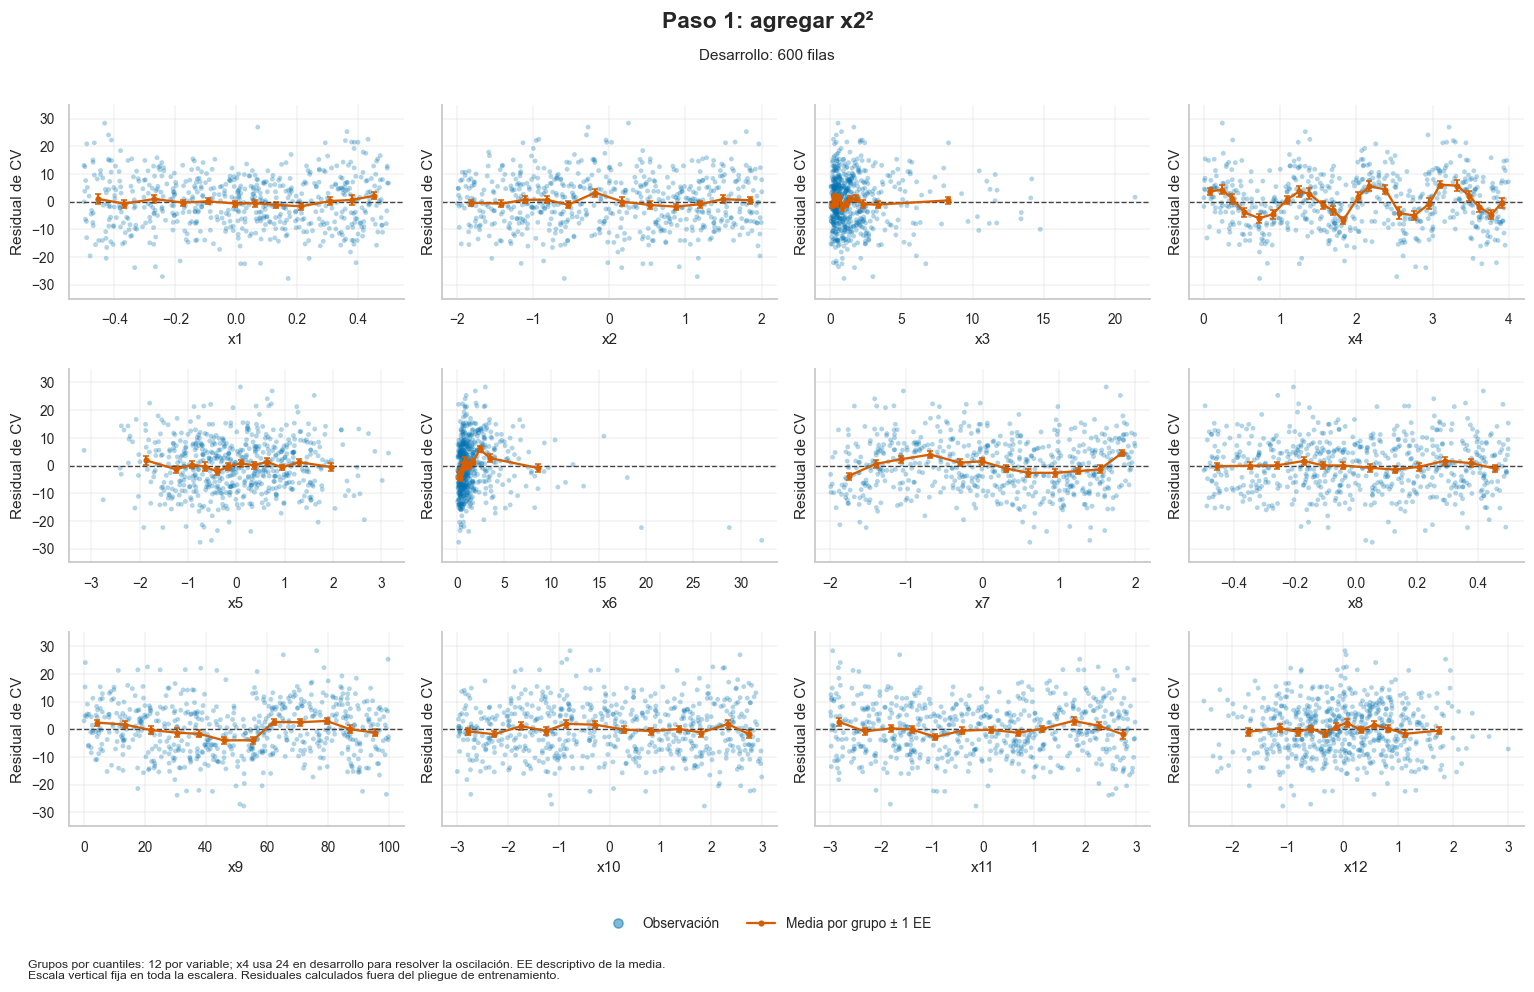

### 2.2 Seno de x4

En x4 hay subidas y bajadas que una recta no representa. Al agregar el seno, el MSE CV baja de 83.34 a 65.90.

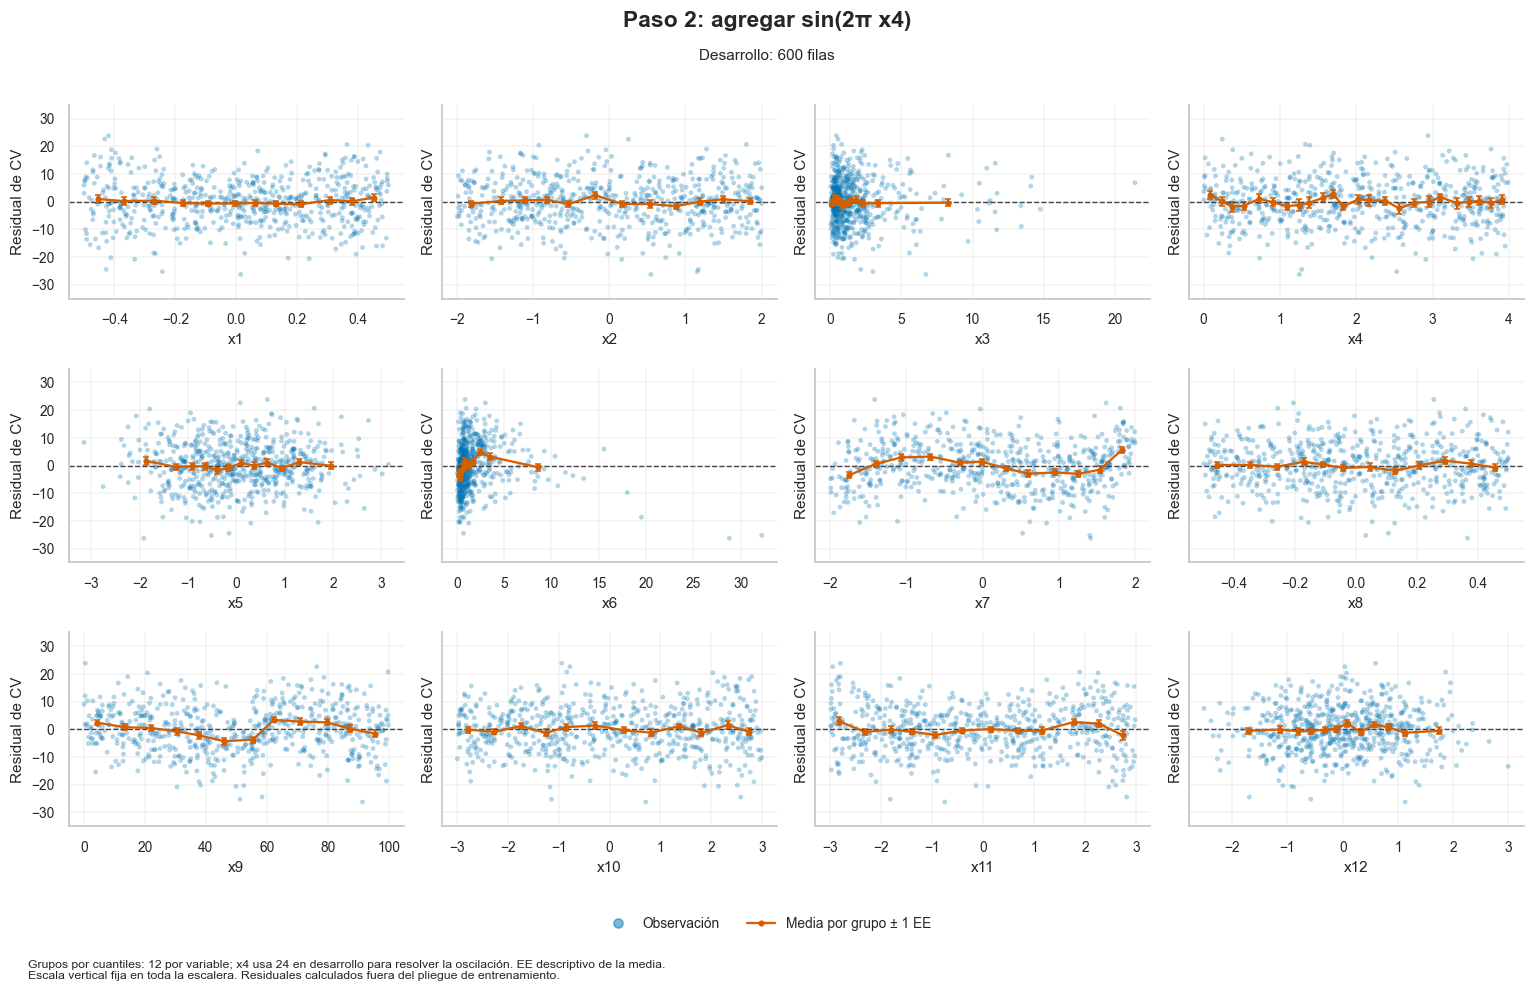

### 2.3 Logaritmo de x6

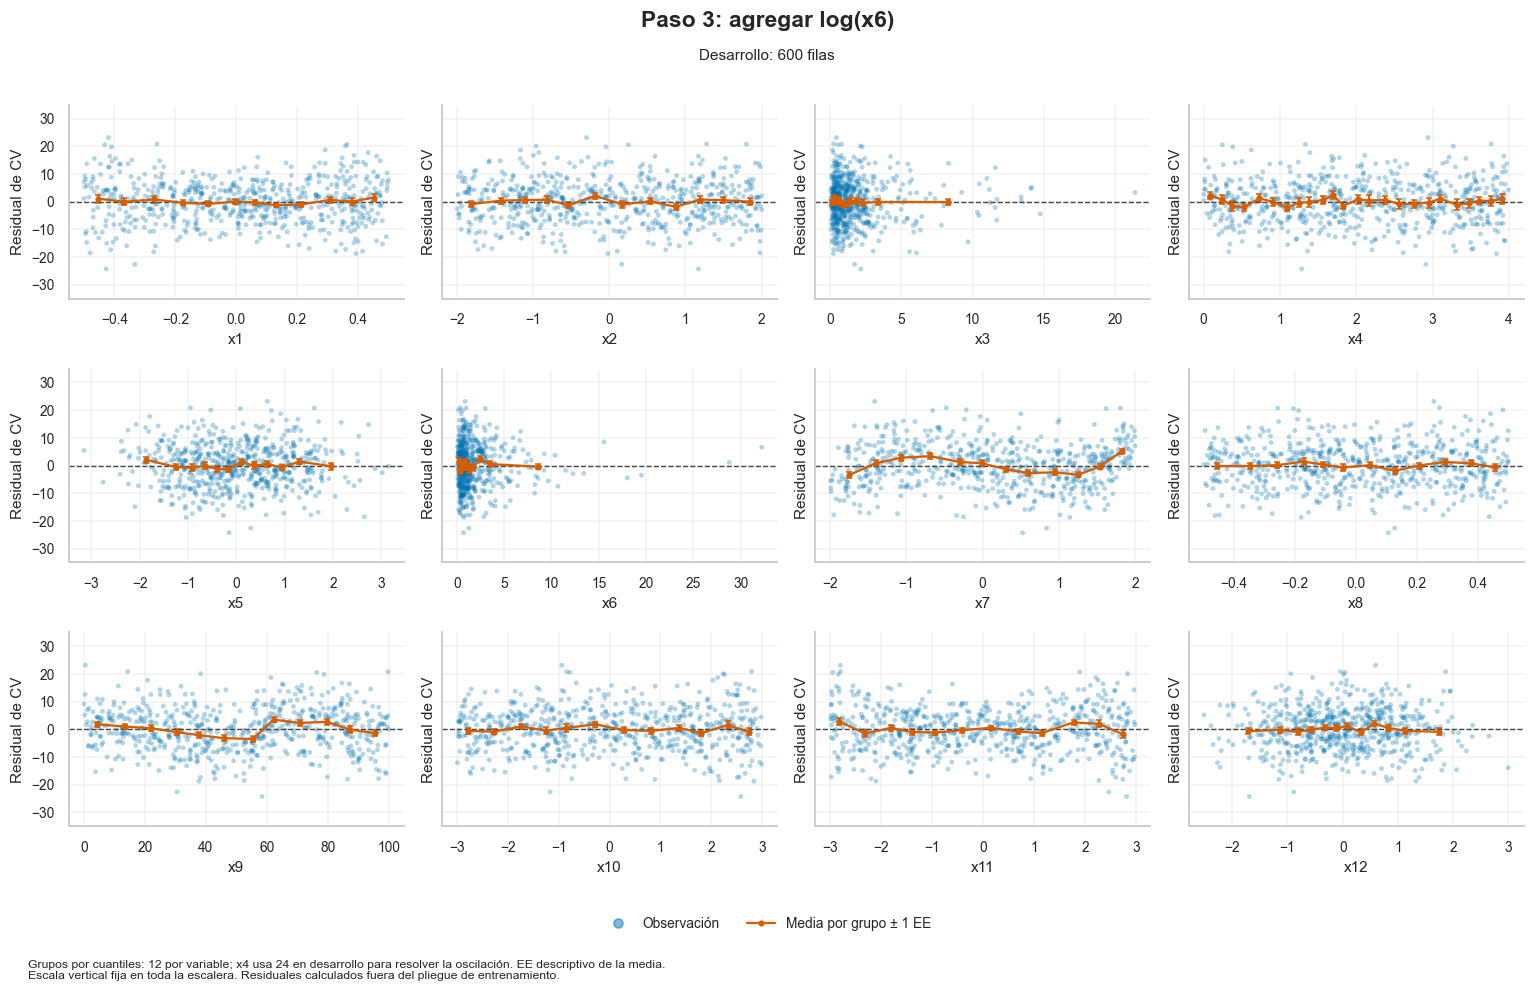

### 2.4 Cubo de x7

El término cúbico representa parte de la curvatura restante en x7. Lo mantengo porque aporta una reducción adicional del error, incluso con las transformaciones anteriores.

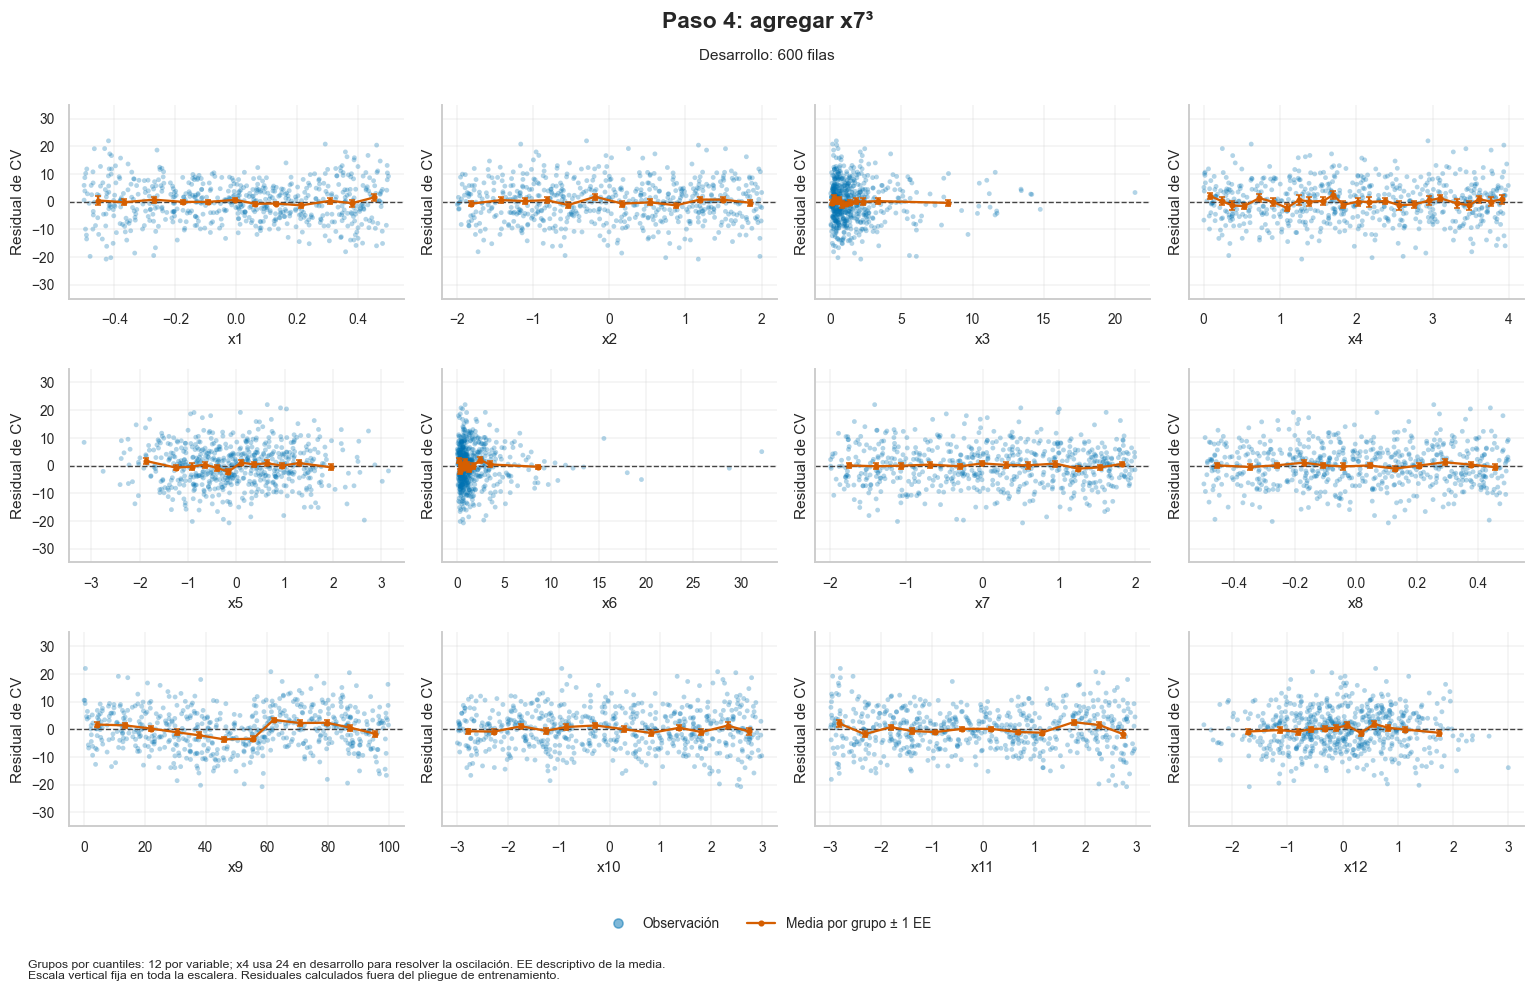

### 2.5 Escalón en x9

El indicador `x9 > 60` permite representar un cambio de nivel. Al agregarlo, el MSE CV baja de 51.02 a 47.02.

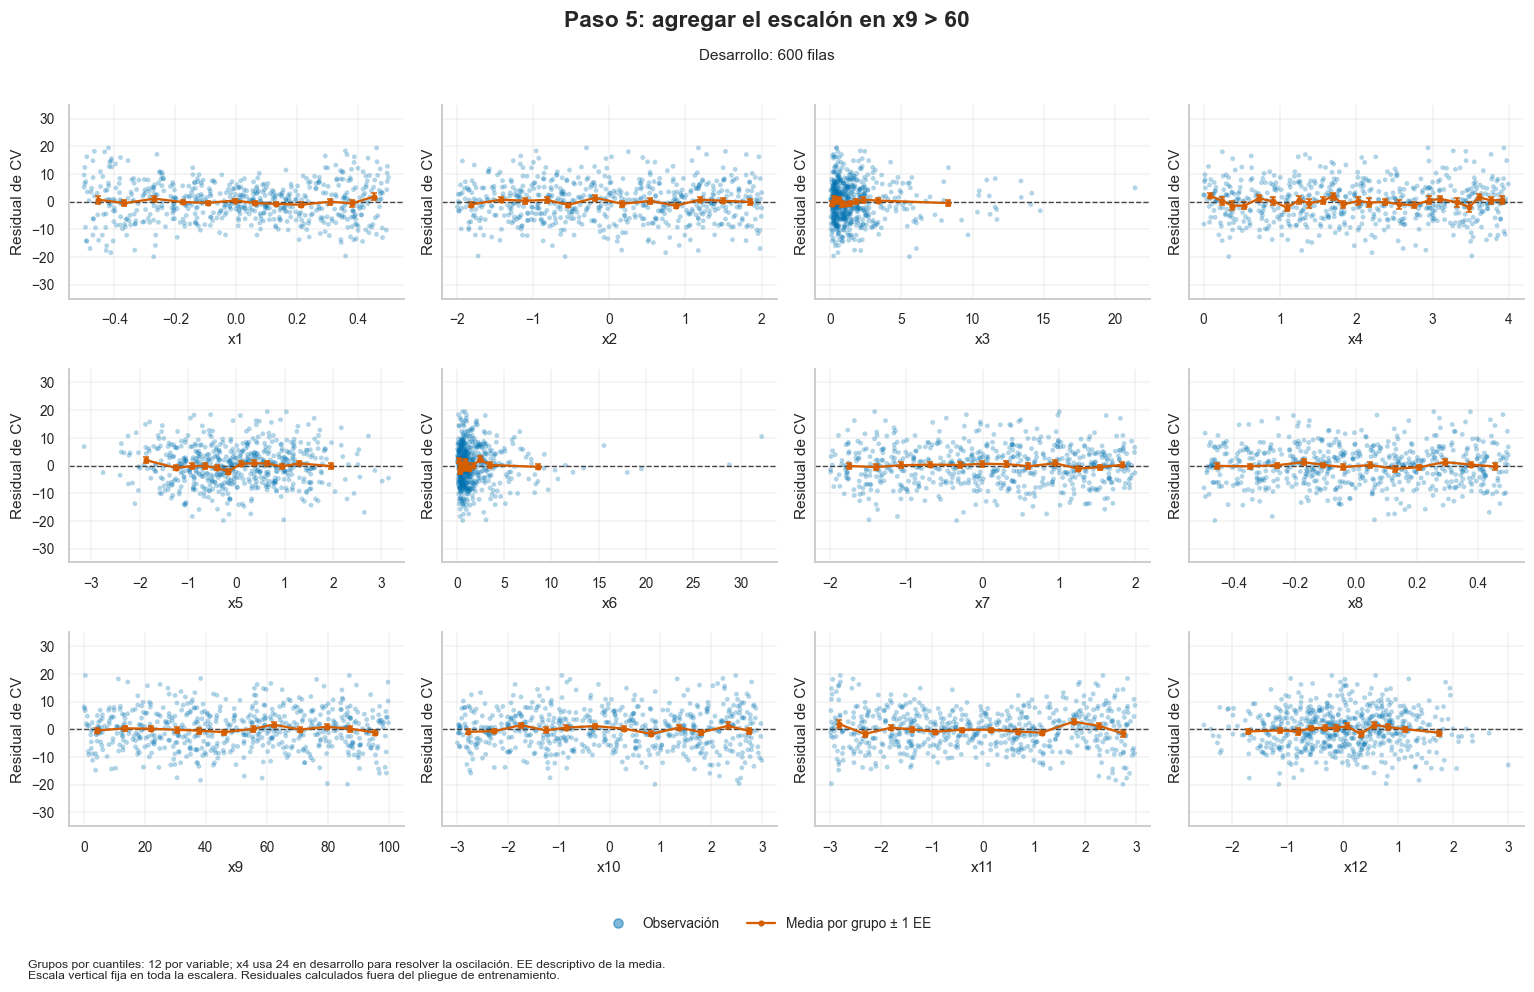

,modelo,columnas,MSE_CV,DE_pliegues
0,Baseline,12,104.6655,15.0910
1,+ x2_cuadrado,13,83.3429,11.7092
2,+ seno_x4,14,65.9044,9.5540
3,+ log_x6,15,58.8534,7.6694
4,+ x7_cubo,16,51.0205,6.0555
5,+ escalon_x9,17,47.0168,5.7489


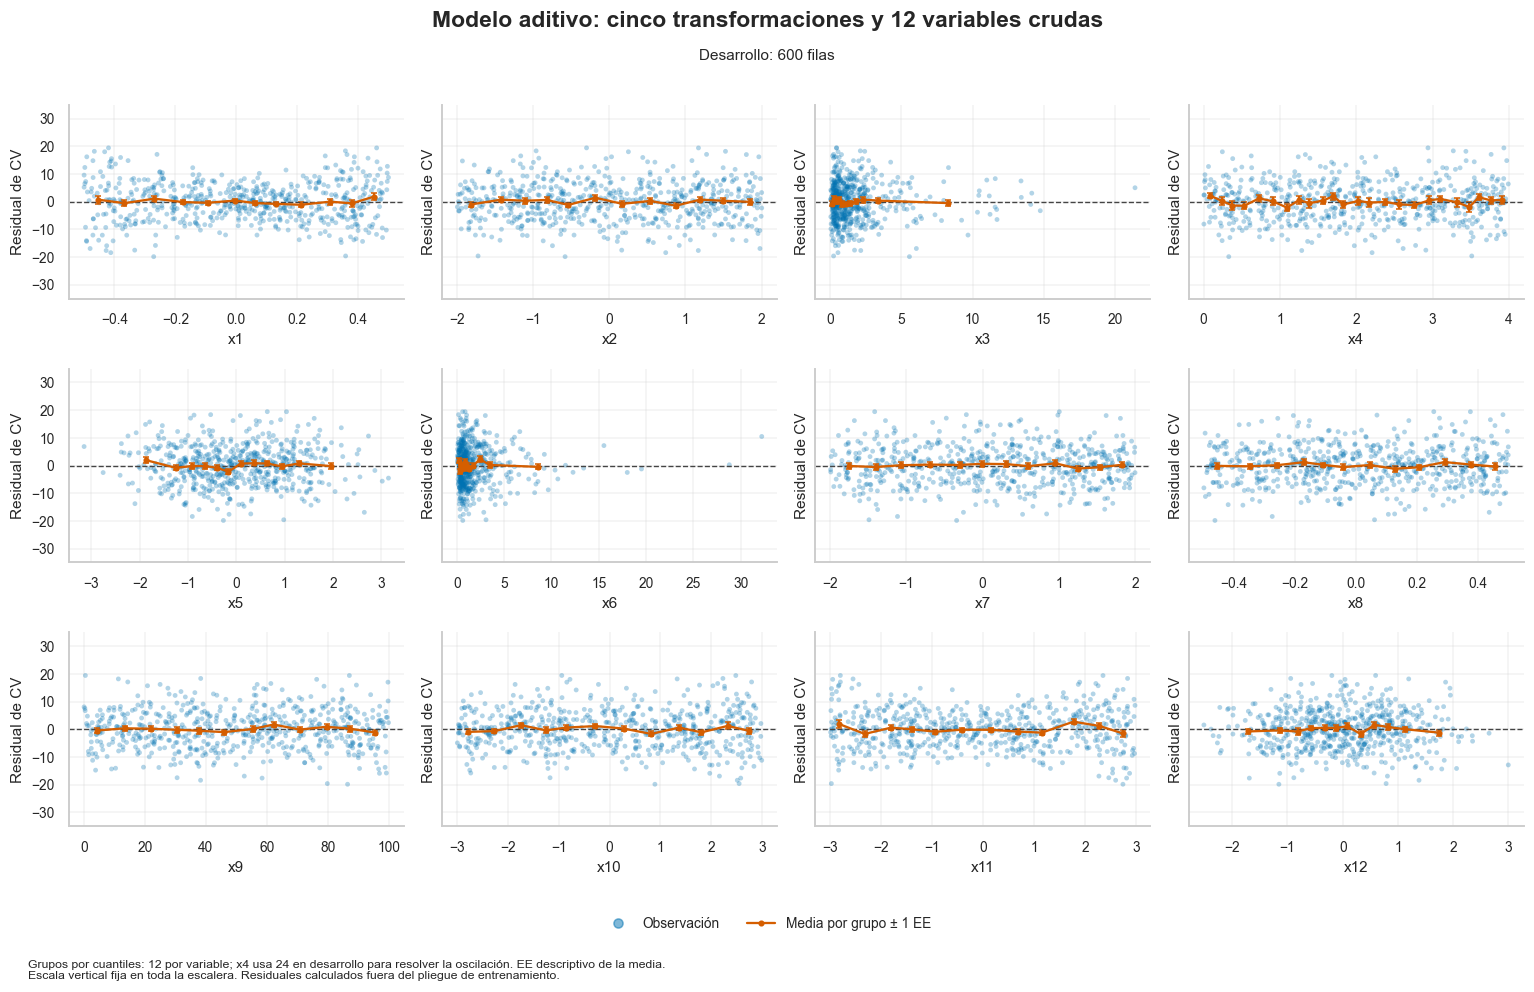

In [8]:
comentarios_etapa = {
    "x2_cuadrado": "Con `x2²`, el MSE CV baja de 104.67 a 83.34. El cuadrado permite "
                   "representar la curvatura que queda con la variable original.",
    "seno_x4": "En x4 hay subidas y bajadas que una recta no representa. Al agregar "
               "el seno, el MSE CV baja de 83.34 a 65.90.",
    "x7_cubo": "El término cúbico representa parte de la curvatura restante en x7. "
               "Lo mantengo porque aporta una reducción adicional del error, "
               "incluso con las transformaciones anteriores.",
    "escalon_x9": "El indicador `x9 > 60` permite representar un cambio de nivel. "
                  "Al agregarlo, el MSE CV baja de 51.02 a 47.02.",
}
titulos_etapa = ["Cuadrado de x2", "Seno de x4", "Logaritmo de x6",
                 "Cubo de x7", "Escalón en x9"]
etapas = [{"modelo": "Baseline", "terminos": [], "crudas": True, **cv_baseline}]
seleccion = []
for paso, nombre in enumerate(list(TERMINOS)[:5], start=1):
    seleccion = seleccion + [nombre]
    matriz_paso = construir(X_train, seleccion)
    etapas.append({"modelo": f"+ {nombre}", "terminos": seleccion.copy(), "crudas": True,
                   **evaluar_cv(matriz_paso)})
    display(Markdown(f"### 2.{paso} {titulos_etapa[paso - 1]}"))
    if nombre in comentarios_etapa:
        display(Markdown(comentarios_etapa[nombre]))
    paneles_respuesta(X_train, residuales_cv(matriz_paso), "Residual de CV",
                     f"residuales_paso_{paso:02d}.png")
display(pd.DataFrame(etapas)[["modelo", "columnas", "MSE_CV", "DE_pliegues"]])
paneles_respuesta(X_train, residuales_cv(matriz_paso),
                 "Residual de CV", "05_residuales_aditivo.png")


## Parte 3. Interacciones

El efecto de x11 depende del valor de x1, algo que puede quedar oculto al mirar
las variables por separado. Al representar los residuales contra `x1*x11`, aparece
una tendencia que disminuye al agregar el producto al modelo. El MSE CV baja de
47.02 a 20.07, una mejora que justifica conservar la interacción.

El producto permite que la pendiente respecto a `x11` cambie con `x1`:
$\partial\widehat y/\partial x_{11}=\beta_{11}+\beta_{1,11}x_1$.
Entre los 66 productos de pares evaluados, `x1*x11` obtiene el menor MSE CV.


,par,MSE_CV,DE_pliegues,columnas
9,x1*x11,20.0671,2.6009,18
39,x5*x7,46.7005,5.8657,18
4,x1*x6,46.8238,5.7449,18
53,x7*x10,46.8309,5.8606,18
50,x6*x12,46.8678,5.7247,18
42,x5*x10,46.8948,5.6103,18
1,x1*x3,46.9472,5.8196,18
8,x1*x10,46.9485,5.6806,18
45,x6*x7,46.9565,5.7265,18
58,x8*x11,47.0102,5.6322,18


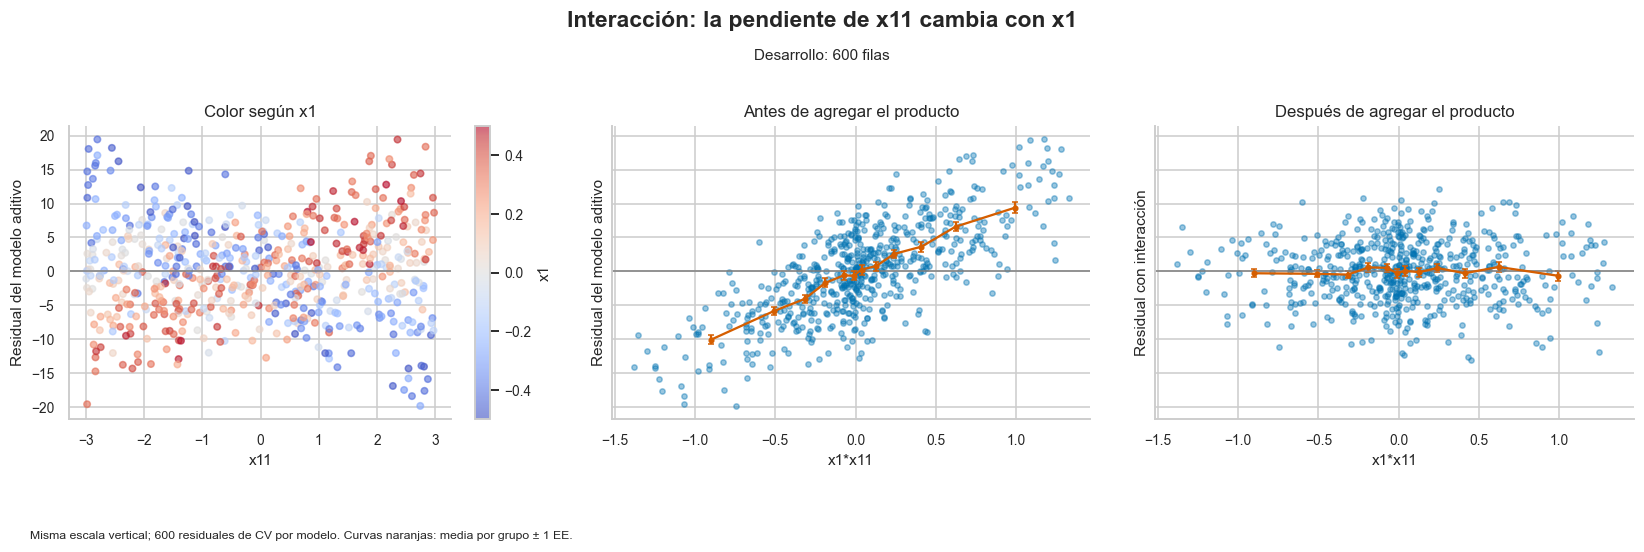

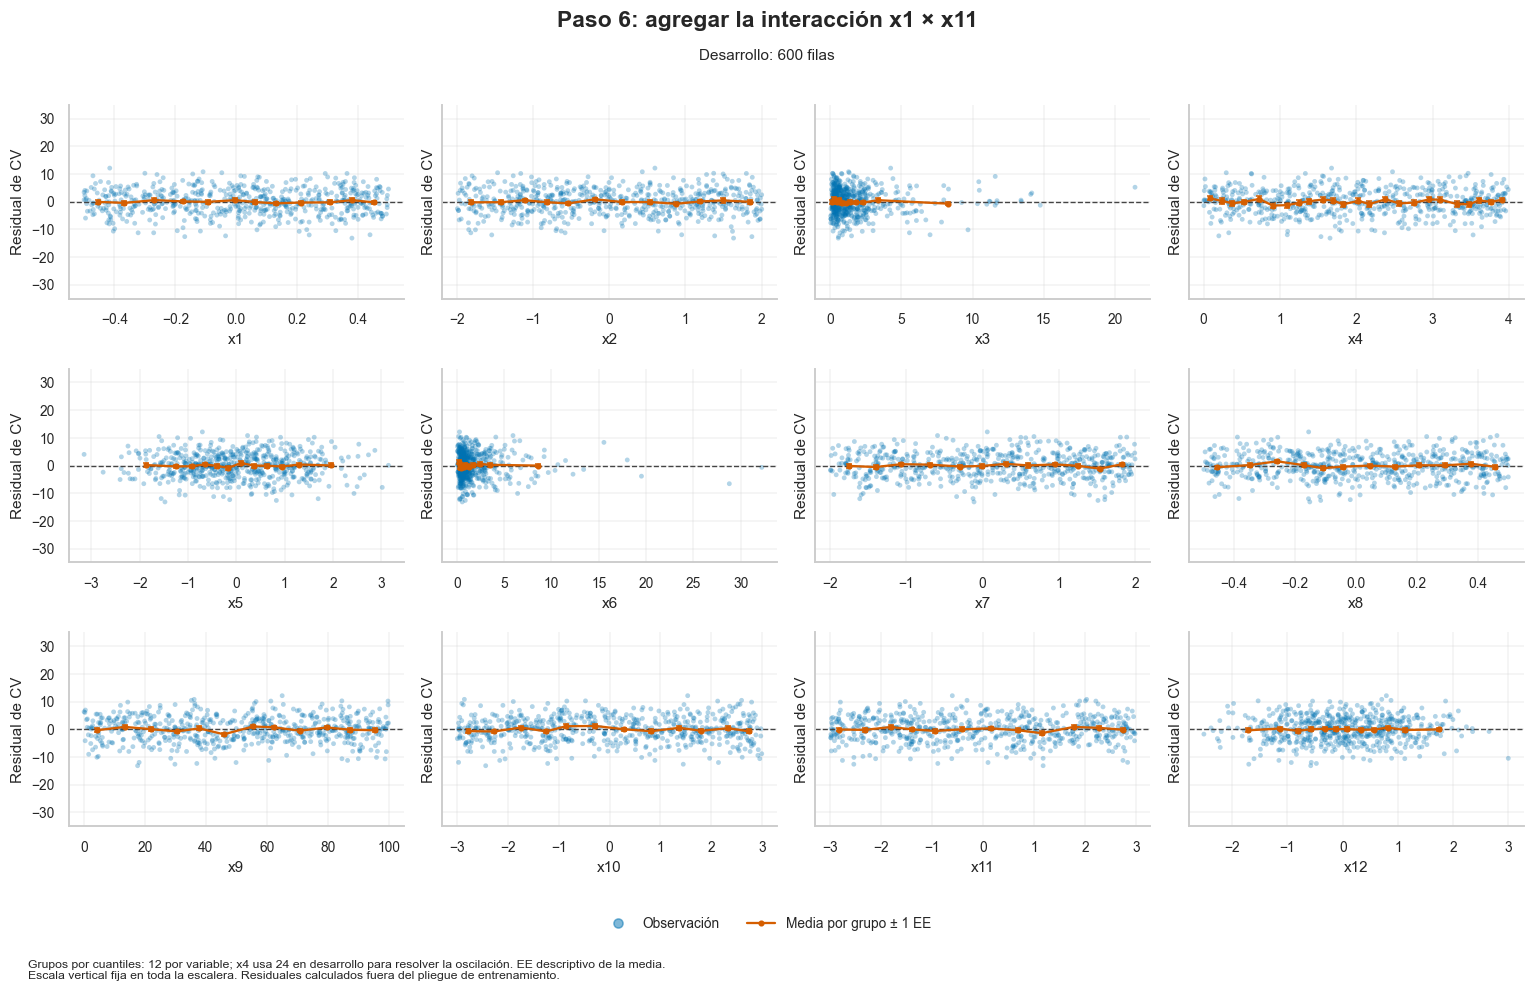

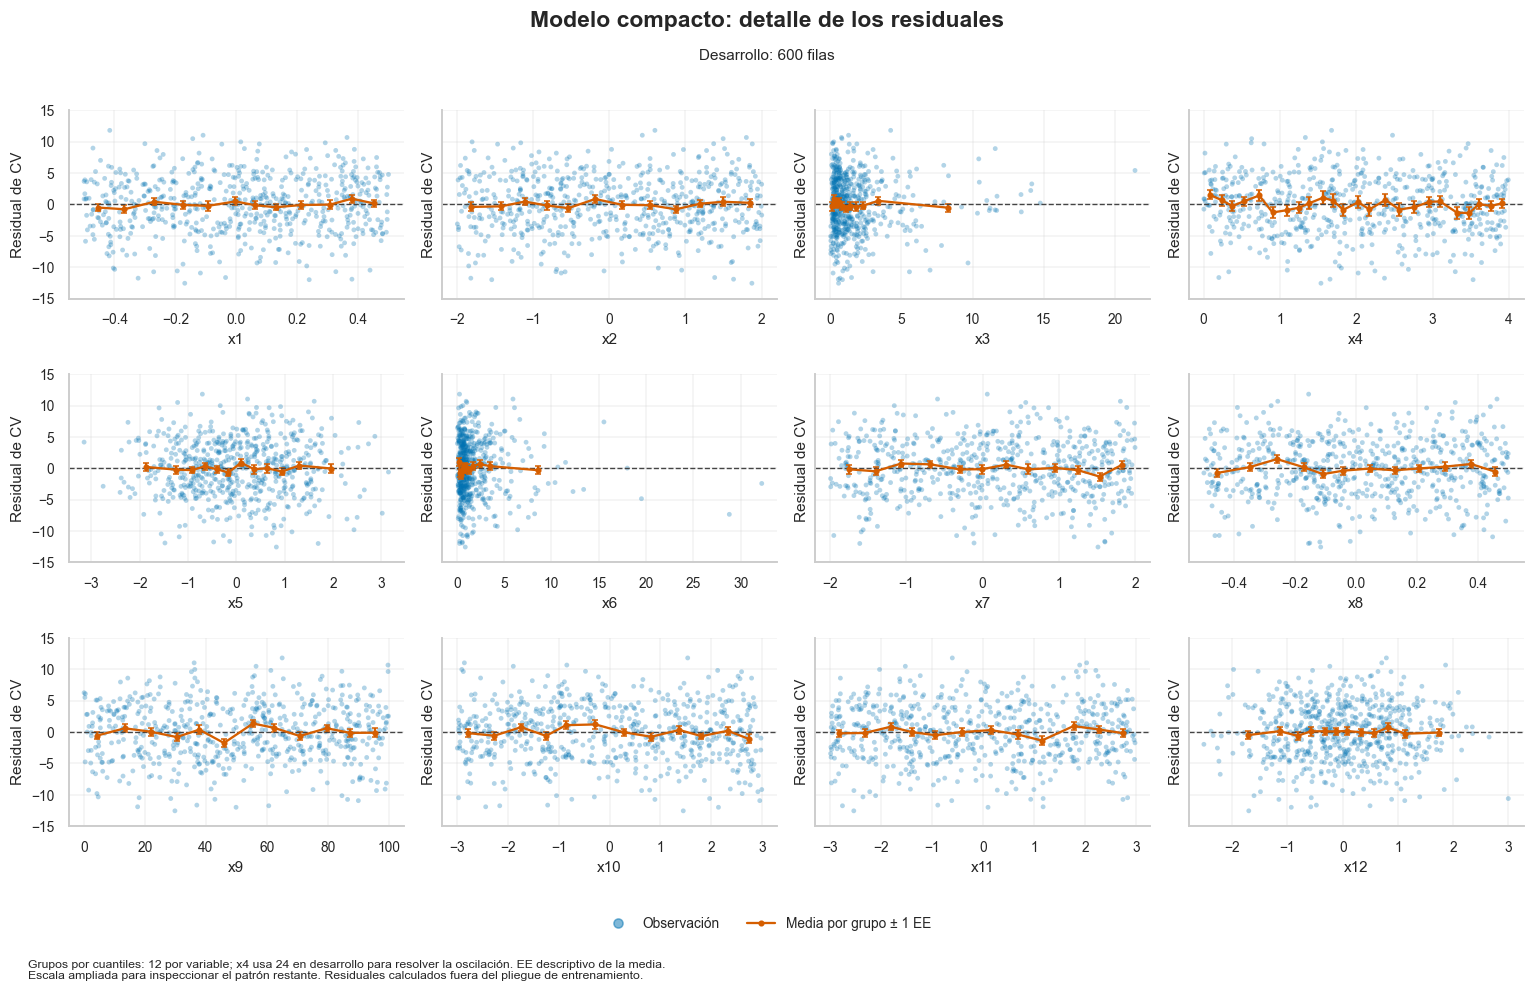

,modelo,columnas,MSE_CV,DE_pliegues
0,Baseline,12,104.6655,15.0910
1,+ x2_cuadrado,13,83.3429,11.7092
2,+ seno_x4,14,65.9044,9.5540
3,+ log_x6,15,58.8534,7.6694
4,+ x7_cubo,16,51.0205,6.0555
5,+ escalon_x9,17,47.0168,5.7489
6,+ interacción x1*x11,18,20.0671,2.6009
7,Compacto: siete columnas,7,19.5950,2.5838


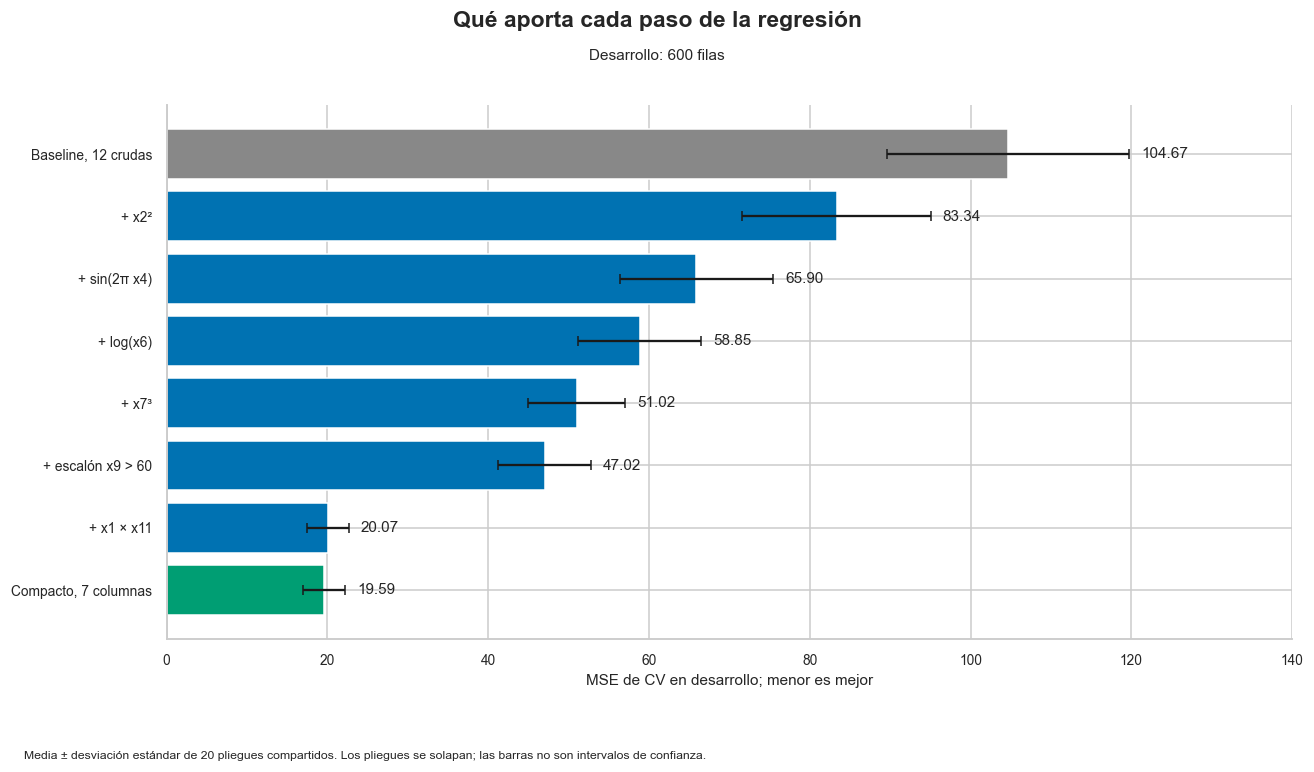

In [9]:
# Comparar todos los productos de dos variables.
matriz_aditiva = construir(X_train, seleccion)
ranking_pares = []
for a, b in combinations(VARIABLES, 2):
    candidato = matriz_aditiva.copy()
    candidato[f"{a}*{b}"] = X_train[a] * X_train[b]
    ranking_pares.append({"par": f"{a}*{b}", **evaluar_cv(candidato)})
tabla_pares = pd.DataFrame(ranking_pares).sort_values("MSE_CV")
tabla_pares.to_csv(RESULTADOS / "interacciones_cv.csv", index=False)
display(tabla_pares.head(10))

residuales_aditivos = residuales_cv(matriz_aditiva)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
nube = axes[0].scatter(X_train["x11"], residuales_aditivos, c=X_train["x1"],
                       cmap="coolwarm", alpha=0.6, s=18)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set(xlabel="x11", ylabel="Residual del modelo aditivo")
fig.colorbar(nube, ax=axes[0], label="x1")
producto = X_train["x1"] * X_train["x11"]
axes[1].scatter(producto, residuales_aditivos, s=12, alpha=0.4)
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set(xlabel="x1*x11", ylabel="Residual del modelo aditivo")
tendencia_por_grupos(axes[1], producto, residuales_aditivos)
res_con_interaccion = residuales_cv(construir(X_train, list(TERMINOS)))
axes[2].scatter(producto, res_con_interaccion, s=12, alpha=0.4, color="#0072B2")
tendencia_por_grupos(axes[2], producto, res_con_interaccion)
axes[2].axhline(0, color="gray", linewidth=1)
axes[2].set(xlabel="x1*x11", ylabel="Residual con interacción")
for ax, titulo_panel in zip(axes, ["Color según x1", "Antes de agregar el producto", "Después de agregar el producto"]):
    ax.set_title(titulo_panel)
guardar_figura("06_interaccion.png", nota="Misma escala vertical; 600 residuales de CV por modelo. Curvas naranjas: media por grupo ± 1 EE.")

seleccion = list(TERMINOS)
etapas.append({"modelo": "+ interacción x1*x11", "terminos": seleccion.copy(), "crudas": True,
               **evaluar_cv(construir(X_train, seleccion))})
paneles_respuesta(X_train, residuales_cv(construir(X_train, seleccion)),
                 "Residual de CV", "residuales_paso_06.png")
etapas.append({"modelo": "Compacto: siete columnas", "terminos": seleccion.copy(), "crudas": False,
               **evaluar_cv(construir(X_train, seleccion, crudas=False))})
paneles_respuesta(X_train, residuales_cv(construir(X_train, seleccion, crudas=False)),
                 "Residual de CV", "residuales_compacto.png")
tabla_escalera = pd.DataFrame(etapas)[["modelo", "columnas", "MSE_CV", "DE_pliegues"]]
tabla_escalera.to_csv(RESULTADOS / "escalera_cv.csv", index=False)
display(tabla_escalera)
fig, ax = plt.subplots(figsize=(12, 7))
etiquetas = ["Baseline, 12 crudas", "+ x2²", "+ sin(2π x4)", "+ log(x6)",
             "+ x7³", "+ escalón x9 > 60", "+ x1 × x11", "Compacto, 7 columnas"]
posiciones = np.arange(len(tabla_escalera))
ax.barh(posiciones, tabla_escalera["MSE_CV"], xerr=tabla_escalera["DE_pliegues"],
        color=["#888888"] + ["#0072B2"] * 6 + ["#009E73"], capsize=3)
ax.set(yticks=posiciones, yticklabels=etiquetas, xlabel="MSE de CV en desarrollo; menor es mejor")
ax.invert_yaxis()
for i, fila in tabla_escalera.iterrows():
    ax.text(fila["MSE_CV"] + fila["DE_pliegues"] + 1.5, i, f"{fila['MSE_CV']:.2f}", va="center")
ax.set_xlim(0, 140)
guardar_figura("10_progreso_modelos.png", titulo="Qué aporta cada paso de la regresión",
               nota="Media ± desviación estándar de 20 pliegues compartidos. Los pliegues se solapan; las barras no son intervalos de confianza.")

### Comparación de alternativas y simplificación

Para `x6` comparo logaritmo, `log1p` y raíz cuadrada, con y sin las variables
originales. También pruebo nueve umbrales entre 58 y 62 para el escalón.
Me quedo con el logaritmo porque mejora el ajuste y también supera a las otras
formas evaluadas. En el modelo compacto obtiene 19.59, frente a 20.45 de `log1p`
y 21.49 de la raíz. En las tres familias, el mejor umbral de esta rejilla es 60.

Cada término del compacto aporta información. Retirar cualquiera aumenta el error,
como mínimo a 27.51. Agregar x6 sin transformar sólo mejora el MSE en 0.0208,
de 19.5950 a 19.5742, una ganancia pequeña para justificar otra columna.

La comparación de seno y coseno a siete frecuencias favorece el seno de frecuencia
1 entre los catorce candidatos. Estas comparaciones respaldan la especificación
dentro de las alternativas evaluadas.


,familia,crudas,umbral,MSE_CV,DE_pliegues,columnas
13,log,False,60.0000,19.5950,2.5838,7
14,log,False,60.2500,19.6915,2.6645,7
15,log,False,60.5000,19.6956,2.6686,7
12,log,False,59.7500,19.7009,2.5116,7
11,log,False,59.5000,19.8367,2.4791,7
16,log,False,61.0000,19.9701,2.5389,7
4,log,True,60.0000,20.0671,2.6009,18
6,log,True,60.5000,20.1481,2.6822,18
3,log,True,59.7500,20.1484,2.5467,18
5,log,True,60.2500,20.1534,2.6695,18


Reemplazar x2² por exp(0.5*x2): MSE CV 20.7490


,extras,MSE_CV,DE_pliegues,columnas
0,ninguna,19.5950,2.5838,7
1,x7,19.6101,2.5212,8
2,x6,19.5742,2.5343,8
3,"x7, x6",19.5995,2.4837,9
4,x9,19.5953,2.6133,8
5,"x7, x6, x9",19.5972,2.5146,10


,contexto,forma,MSE_CV,DE_pliegues,columnas
0,Baseline + un término,cuadrado,83.3429,11.7092,13
1,Baseline + un término,exponencial,83.4130,11.9177,13
2,Con los demás términos,cuadrado,20.0671,2.6009,18
3,Con los demás términos,exponencial,20.7490,2.5821,18


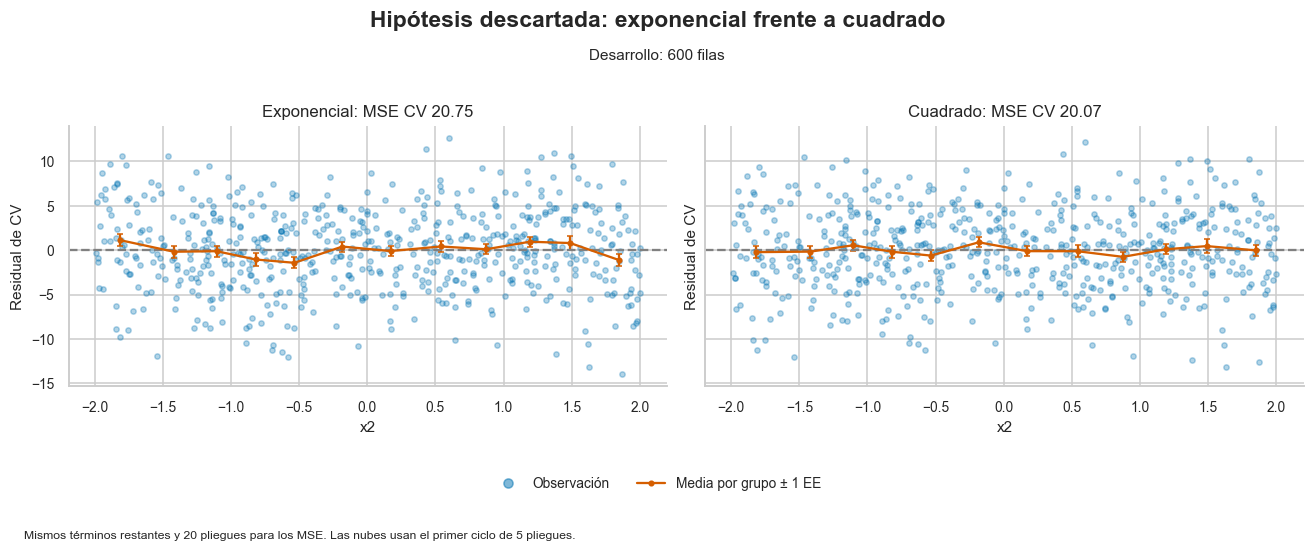

,retirado,MSE_CV,DE_pliegues,columnas,aumento_MSE
0,ninguno,19.5950,2.5838,7,0.0000
1,x11,27.5077,3.6260,6,7.9127
2,x2_cuadrado,42.0440,4.3581,6,22.4490
3,seno_x4,45.0348,5.4751,6,25.4398
4,log_x6,30.0693,3.9735,6,10.4743
5,x7_cubo,61.7616,6.1047,6,42.1666
6,escalon_x9,41.6666,3.7465,6,22.0716
7,interaccion_x1_x11,45.6565,5.7808,6,26.0615


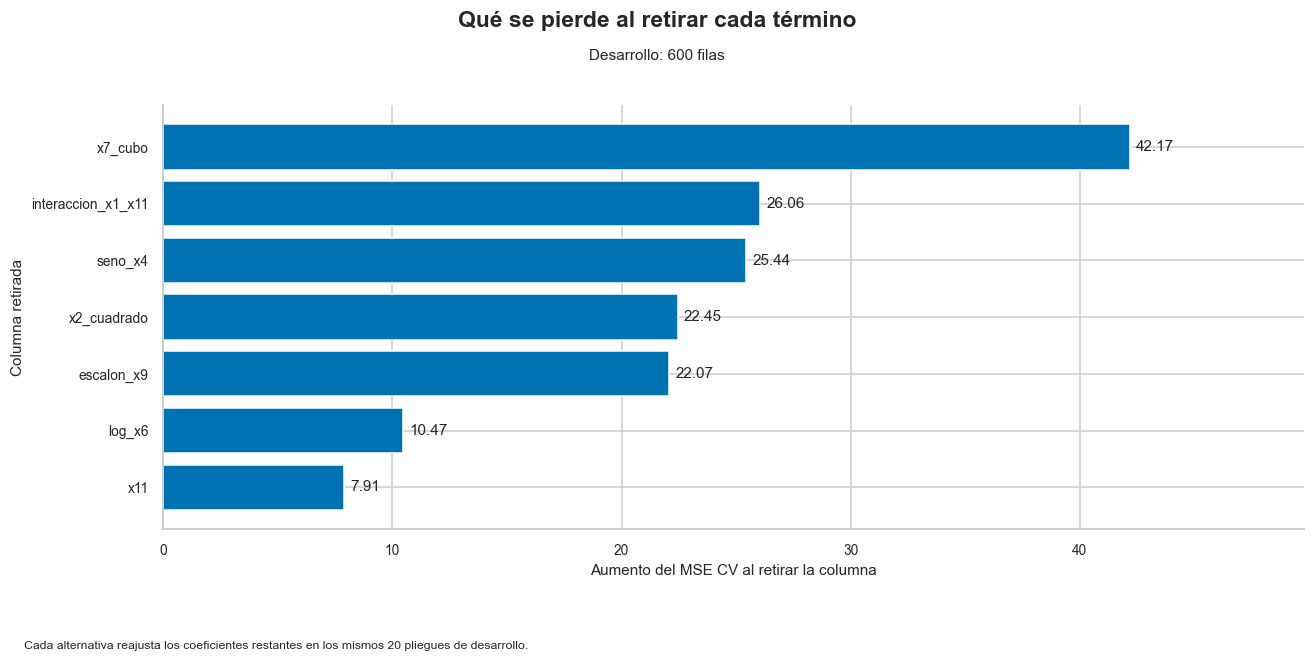

,familia,frecuencia,MSE_CV,DE_pliegues,columnas
3,seno,1.0000,19.5950,2.5838,7
1,seno,0.5000,44.8295,5.5375,7
13,coseno,2.0000,44.8759,5.2926,7
0,seno,0.2500,44.9389,5.4608,7
12,coseno,1.5000,44.9542,5.3192,7


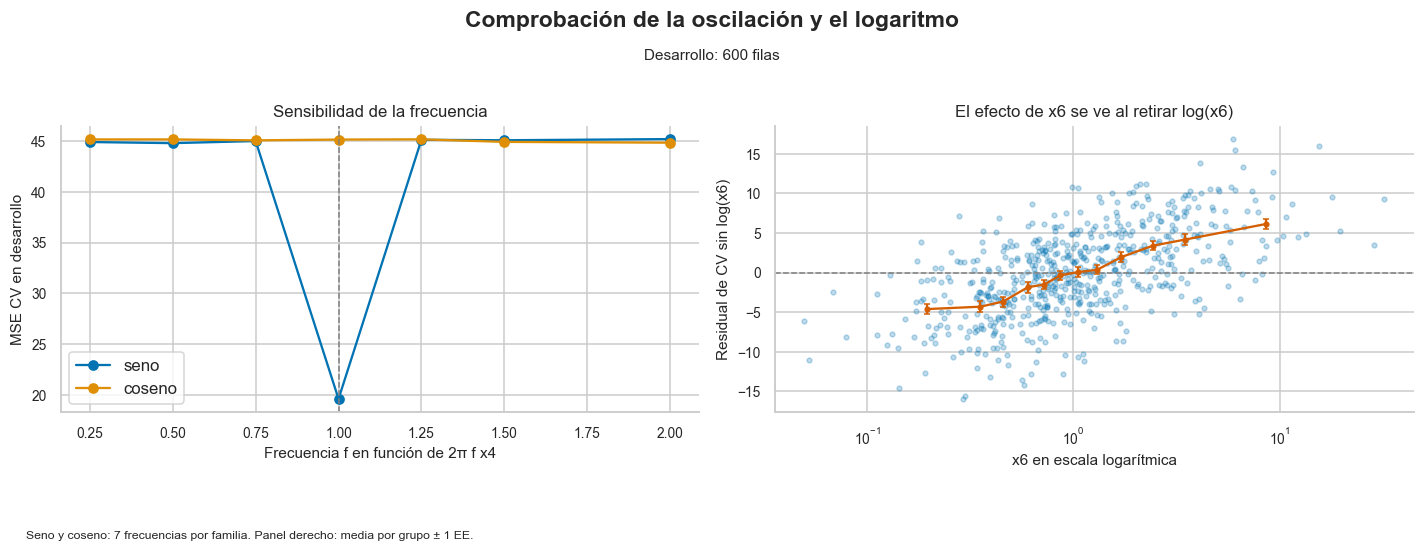

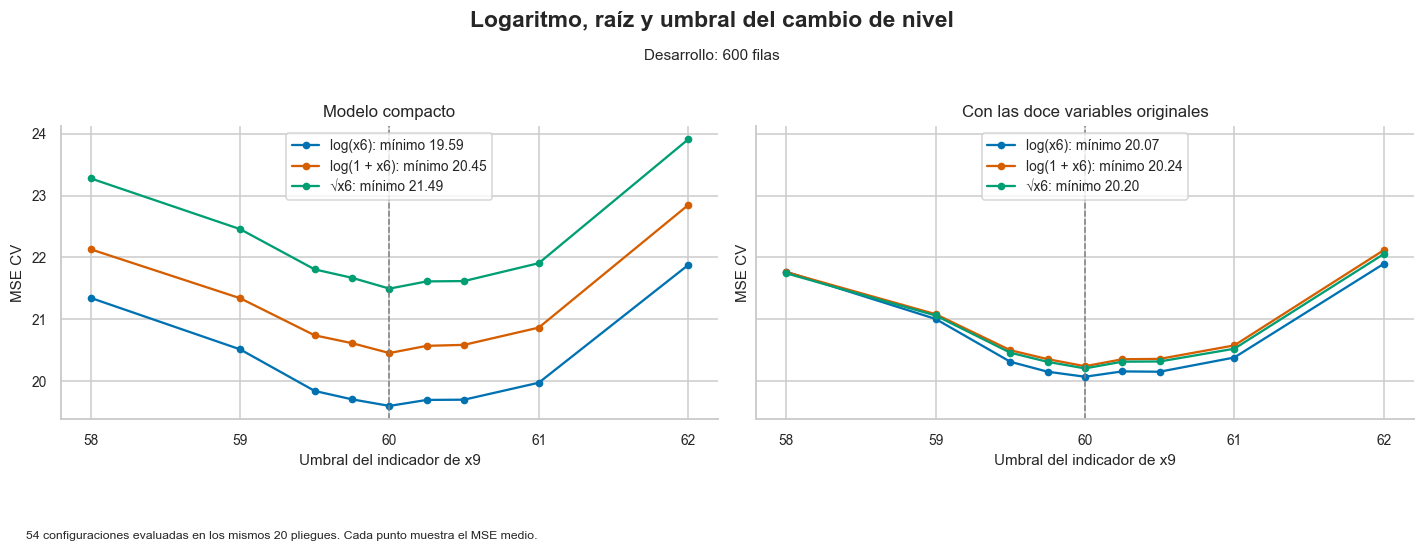

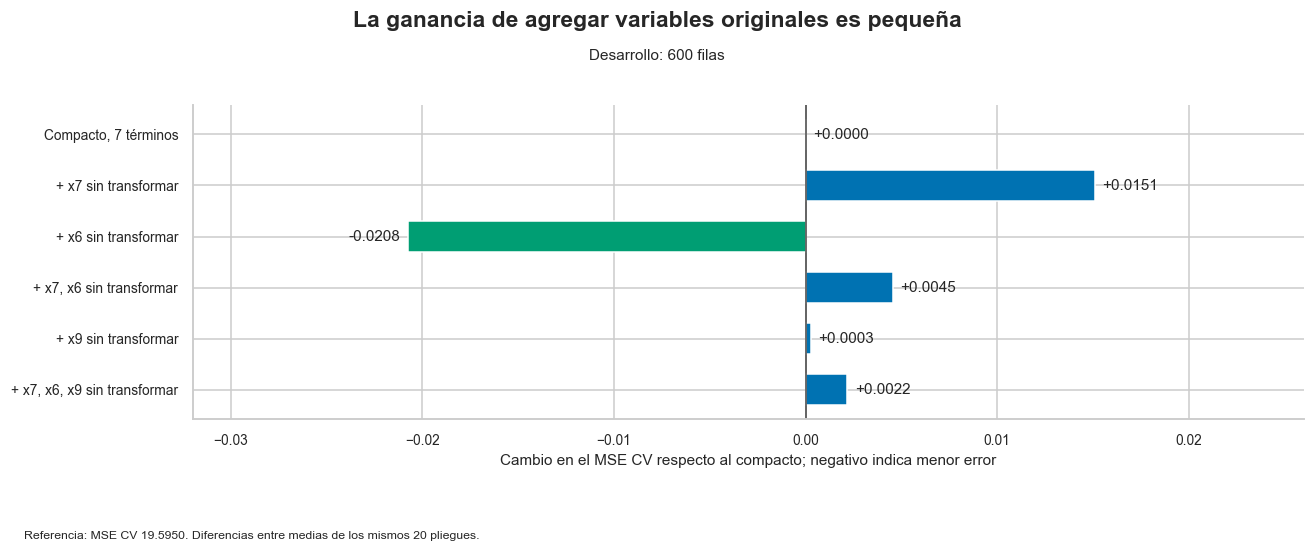

In [10]:
alternativas = []
for familia, funcion in [("log", np.log), ("log1p", np.log1p), ("sqrt", np.sqrt)]:
    for crudas in [True, False]:
        for umbral in [58, 59, 59.5, 59.75, 60, 60.25, 60.5, 61, 62]:
            matriz = construir(X_train, seleccion, crudas=crudas)
            matriz["log_x6"] = funcion(X_train["x6"])
            matriz["escalon_x9"] = (X_train["x9"] > umbral).astype(float)
            alternativas.append({"familia": familia, "crudas": crudas, "umbral": umbral,
                                  **evaluar_cv(matriz)})
tabla_alternativas = pd.DataFrame(alternativas).sort_values("MSE_CV")
tabla_alternativas.to_csv(RESULTADOS / "alternativas_cv.csv", index=False)
display(tabla_alternativas.head(10))

matriz_exponencial = construir(X_train, seleccion).drop(columns="x2_cuadrado")
matriz_exponencial["exp_x2"] = np.exp(0.5 * X_train["x2"])
cv_exponencial = evaluar_cv(matriz_exponencial)
print(f"Reemplazar x2² por exp(0.5*x2): MSE CV {cv_exponencial['MSE_CV']:.4f}")

# Sensibilidad: agregar variables crudas a las siete columnas ya elegidas.
sensibilidad = []
for extras in [[], ["x7"], ["x6"], ["x7", "x6"], ["x9"], ["x7", "x6", "x9"]]:
    matriz = construir(X_train, seleccion, crudas=False)
    for variable in extras:
        matriz[variable] = X_train[variable]
    sensibilidad.append({"extras": ", ".join(extras) or "ninguna", **evaluar_cv(matriz)})
tabla_sensibilidad = pd.DataFrame(sensibilidad)
tabla_sensibilidad.to_csv(RESULTADOS / "sensibilidad_cv.csv", index=False)
display(tabla_sensibilidad)

# Comparar cuadrado y exponencial en dos contextos.
filas_exponencial = []
for contexto in ["Baseline + un término", "Con los demás términos"]:
    for forma in ["cuadrado", "exponencial"]:
        if contexto == "Baseline + un término":
            matriz = X_train.copy()
            matriz["candidato_x2"] = X_train["x2"] ** 2 if forma == "cuadrado" else np.exp(0.5 * X_train["x2"])
        else:
            matriz = construir(X_train, seleccion) if forma == "cuadrado" else matriz_exponencial
        filas_exponencial.append({"contexto": contexto, "forma": forma, **evaluar_cv(matriz)})
tabla_exponencial = pd.DataFrame(filas_exponencial)
tabla_exponencial.to_csv(RESULTADOS / "exponencial_cv.csv", index=False)
display(tabla_exponencial)

# Comparar los residuales de ambas transformaciones.
res_exponencial = residuales_cv(matriz_exponencial)
res_cuadrado = residuales_cv(construir(X_train, seleccion))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, residuos, titulo in zip(axes, [res_exponencial, res_cuadrado],
                               ["Exponencial descartada", "Cuadrado conservado"]):
    ax.scatter(X_train["x2"], residuos, alpha=0.3, s=12, color="#0072B2")
    tendencia_por_grupos(ax, X_train["x2"], residuos)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set(xlabel="x2", ylabel="Residual de CV", title=titulo)
axes[0].set_title(f"Exponencial: MSE CV {cv_exponencial['MSE_CV']:.2f}")
axes[1].set_title(f"Cuadrado: MSE CV {etapas[-2]['MSE_CV']:.2f}")
guardar_figura("hipotesis_exponencial.png", leyenda=True,
               nota="Mismos términos restantes y 20 pliegues para los MSE. Las nubes usan el primer ciclo de 5 pliegues.")

# Medir el cambio de error al retirar cada columna.
matriz_compacta = construir(X_train, seleccion, crudas=False)
cv_compacto = evaluar_cv(matriz_compacta)
filas_ablacion = [{"retirado": "ninguno", **cv_compacto, "aumento_MSE": 0.0}]
for columna in matriz_compacta:
    resultado = evaluar_cv(matriz_compacta.drop(columns=columna))
    filas_ablacion.append({"retirado": columna, **resultado,
                          "aumento_MSE": resultado["MSE_CV"] - cv_compacto["MSE_CV"]})
tabla_ablacion = pd.DataFrame(filas_ablacion)
tabla_ablacion.to_csv(RESULTADOS / "ablacion_cv.csv", index=False)
display(tabla_ablacion)
resumen_ablacion = tabla_ablacion.iloc[1:].sort_values("aumento_MSE")
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(resumen_ablacion["retirado"], resumen_ablacion["aumento_MSE"], color="#0072B2")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=4)
ax.set(xlabel="Aumento del MSE CV al retirar la columna", ylabel="Columna retirada")
ax.set_xlim(0, resumen_ablacion["aumento_MSE"].max() * 1.18)
guardar_figura("11_ablacion_terminos.png", titulo="Qué se pierde al retirar cada término",
               nota="Cada alternativa reajusta los coeficientes restantes en los mismos 20 pliegues de desarrollo.")

filas_frecuencia = []
for familia, funcion in [("seno", np.sin), ("coseno", np.cos)]:
    for frecuencia in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
        matriz = matriz_compacta.copy()
        matriz["seno_x4"] = funcion(2 * np.pi * frecuencia * X_train["x4"])
        filas_frecuencia.append({"familia": familia, "frecuencia": frecuencia, **evaluar_cv(matriz)})
tabla_frecuencias = pd.DataFrame(filas_frecuencia)
tabla_frecuencias.to_csv(RESULTADOS / "frecuencia_x4_cv.csv", index=False)
display(tabla_frecuencias.sort_values("MSE_CV").head())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for familia, grupo in tabla_frecuencias.groupby("familia", sort=False):
    axes[0].plot(grupo["frecuencia"], grupo["MSE_CV"], "o-", label=familia)
axes[0].axvline(1.0, color="gray", linestyle="--", linewidth=1)
axes[0].set(xlabel="Frecuencia f en función de 2π f x4", ylabel="MSE CV en desarrollo",
            title="Sensibilidad de la frecuencia")
axes[0].legend()
sin_log = matriz_compacta.drop(columns="log_x6")
axes[1].scatter(X_train["x6"], residuales_cv(sin_log), s=10, alpha=0.25, color="#0072B2")
tendencia_por_grupos(axes[1], X_train["x6"], residuales_cv(sin_log))
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set(xscale="log", xlabel="x6 en escala logarítmica", ylabel="Residual de CV sin log(x6)",
            title="El efecto de x6 se ve al retirar log(x6)")
guardar_figura("12_formas_funcionales.png", titulo="Comprobación de la oscilación y el logaritmo",
               nota="Seno y coseno: 7 frecuencias por familia. Panel derecho: media por grupo ± 1 EE.")

# Comparar las tres transformaciones y los nueve umbrales evaluados.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
formas_x6 = [("log", "log(x6)", "#0072B2"),
             ("log1p", "log(1 + x6)", "#D55E00"),
             ("sqrt", "√x6", "#009E73")]
for ax, crudas, titulo in zip(axes, [False, True],
                             ["Modelo compacto", "Con las doce variables originales"]):
    for familia, etiqueta, color in formas_x6:
        grupo = tabla_alternativas.loc[(tabla_alternativas["familia"] == familia)
                                       & (tabla_alternativas["crudas"] == crudas)].sort_values("umbral")
        ax.plot(grupo["umbral"], grupo["MSE_CV"], "o-", color=color, markersize=4,
                label=f"{etiqueta}: mínimo {grupo['MSE_CV'].min():.2f}")
    ax.axvline(60, color="gray", linestyle="--", linewidth=1)
    ax.set(xlabel="Umbral del indicador de x9", ylabel="MSE CV", title=titulo,
           xticks=[58, 59, 60, 61, 62])
    ax.legend(loc="upper center", fontsize=9)
guardar_figura("13_alternativas_x6.png", titulo="Logaritmo, raíz y umbral del cambio de nivel",
               nota="54 configuraciones evaluadas en los mismos 20 pliegues. Cada punto muestra el MSE medio.")

# Mostrar la magnitud de las diferencias al agregar columnas originales.
resumen_sensibilidad = tabla_sensibilidad.copy()
referencia = resumen_sensibilidad.loc[resumen_sensibilidad["extras"] == "ninguna", "MSE_CV"].iloc[0]
resumen_sensibilidad["cambio_MSE"] = resumen_sensibilidad["MSE_CV"] - referencia
fig, ax = plt.subplots(figsize=(12, 5))
posiciones = np.arange(len(resumen_sensibilidad))
etiquetas = ["Compacto, 7 términos" if x == "ninguna" else f"+ {x} sin transformar"
             for x in resumen_sensibilidad["extras"]]
colores = ["#009E73" if d < 0 else "#0072B2" for d in resumen_sensibilidad["cambio_MSE"]]
ax.barh(posiciones, resumen_sensibilidad["cambio_MSE"], color=colores, height=0.6)
ax.axvline(0, color="#444444", linewidth=1)
for i, cambio in enumerate(resumen_sensibilidad["cambio_MSE"]):
    ax.annotate(f"{cambio:+.4f}", (cambio, i), xytext=(-5 if cambio < 0 else 5, 0),
                textcoords="offset points", ha="right" if cambio < 0 else "left", va="center")
ax.set(yticks=posiciones, yticklabels=etiquetas, xlim=(-0.032, 0.026),
       xlabel="Cambio en el MSE CV respecto al compacto; negativo indica menor error")
ax.invert_yaxis()
guardar_figura("14_sensibilidad_variables.png", titulo="La ganancia de agregar variables originales es pequeña",
               nota=f"Referencia: MSE CV {referencia:.4f}. Diferencias entre medias de los mismos 20 pliegues.")


## Parte 4. Fuerza bruta: polinomios y LassoCV

El pipeline `PolynomialFeatures(3, include_bias=False) → StandardScaler → LassoCV`
genera 454 columnas. La estandarización permite aplicar la penalización L1 en
escalas comparables; el intercepto queda fuera de la penalización.

`LassoCV` elige entre 60 valores de `alpha`, de 0.032 a 31.6, con cinco pliegues
internos. Para medir el error de comparación se reajusta el pipeline completo en
cada uno de los veinte pliegues de desarrollo. El escalador se ajusta sólo con
el entrenamiento de cada pliegue externo. La CV interna opera sobre esa matriz
estandarizada y se utiliza para elegir `alpha`.


LassoCV: alpha = 0.525217; 34/454 columnas no nulas.


,termino,coeficiente_estandarizado,activo
398,x7^3,5.2560,True
22,x1 x11,4.0726,True
80,x9^2,3.1968,True
24,x2^2,2.5558,True
10,x11,1.9093,True
175,x2^2 x9,1.6987,True
5,x6,1.4349,True
3,x4,-0.9267,True
336,x5^2 x7,0.5038,True
414,x7 x10 x11,0.4370,True


,modelo,MSE_CV,DE_pliegues,columnas
0,Lineal crudo,104.6655,15.0910,12
1,Lineal compacto,19.5950,2.5838,7
2,Polinomio grado 3 + LassoCV,57.3492,6.7840,454
3,Polinomio grado 2 + OLS,71.7718,14.6886,90
4,Polinomio grado 3 + OLS,25089.0639,41000.2409,454


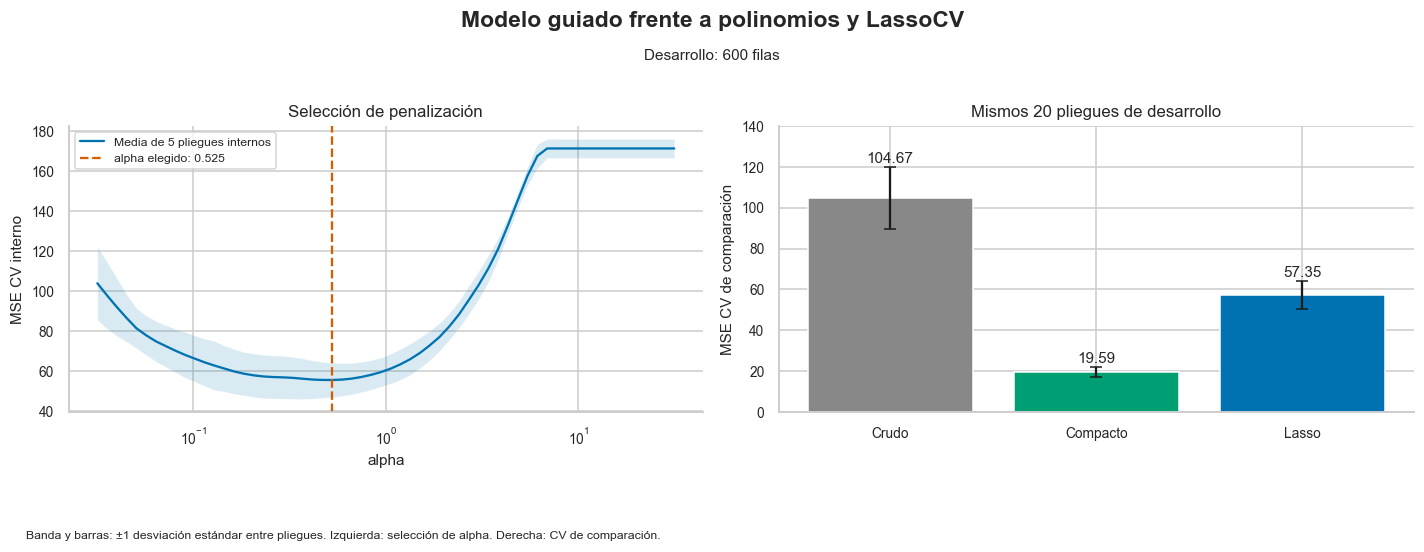

Menor MSE CV entre las dos estrategias: Compacto.


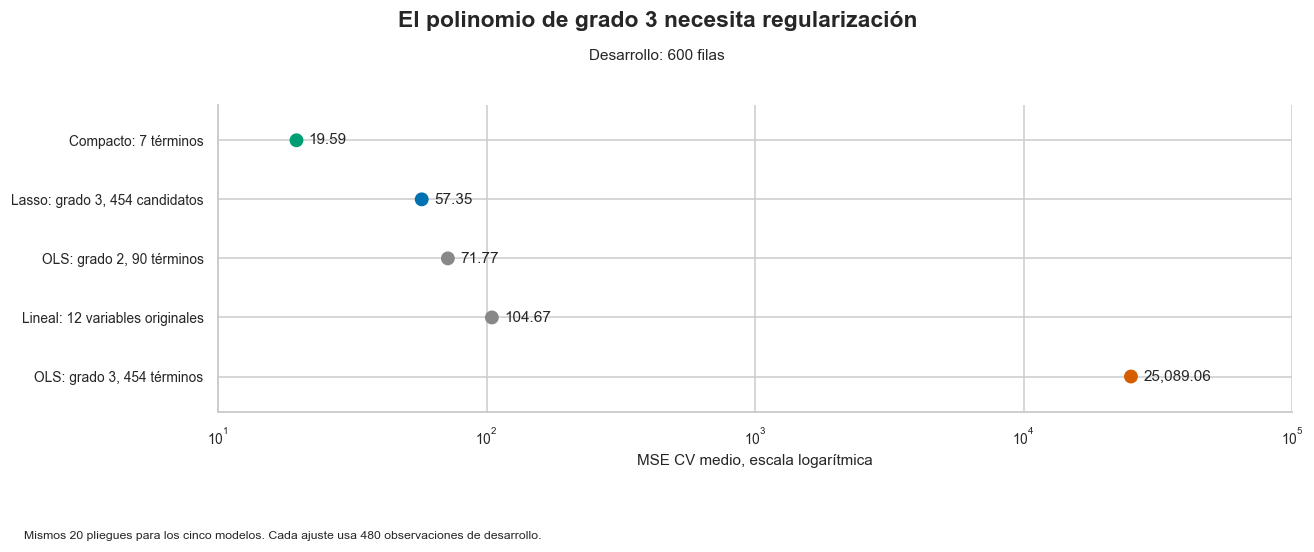

In [11]:
def crear_lasso():
    """Expansión de grado 3, estandarización y selección de la penalización L1."""
    return make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),
        StandardScaler(),
        LassoCV(alphas=np.logspace(-1.5, 1.5, 60),
                cv=KFold(n_splits=5, shuffle=True, random_state=SEMILLA),
                max_iter=50000, tol=1e-4, n_jobs=1, selection="cyclic"),
    )


def revisar_lasso(pipeline, filas):
    ajuste = pipeline.named_steps["lassocv"]
    assert pipeline.named_steps["polynomialfeatures"].n_output_features_ == 454
    assert int(pipeline.named_steps["standardscaler"].n_samples_seen_) == filas
    assert ajuste.n_iter_ < ajuste.max_iter
    assert np.isfinite(ajuste.coef_).all()
    assert ajuste.alphas_.min() < ajuste.alpha_ < ajuste.alphas_.max()


modelo_lasso = crear_lasso().fit(X_train, y_train)
revisar_lasso(modelo_lasso, len(X_train))
ajuste_lasso = modelo_lasso.named_steps["lassocv"]
nombres_polinomio = modelo_lasso.named_steps["polynomialfeatures"].get_feature_names_out(VARIABLES)
coeficientes_lasso = pd.DataFrame({"termino": nombres_polinomio,
                                  "coeficiente_estandarizado": ajuste_lasso.coef_})
coeficientes_lasso["activo"] = coeficientes_lasso["coeficiente_estandarizado"] != 0
coeficientes_lasso.to_csv(RESULTADOS / "coeficientes_lasso.csv", index=False)
no_cero_lasso = int(coeficientes_lasso["activo"].sum())
print(f"LassoCV: alpha = {ajuste_lasso.alpha_:.6f}; {no_cero_lasso}/454 columnas no nulas.")
display(coeficientes_lasso.loc[coeficientes_lasso["activo"]].sort_values(
    "coeficiente_estandarizado", key=abs, ascending=False).head(15))

filas_lasso_cv = []
for numero, (indices_train, indices_val) in enumerate(PLIEGUES, start=1):
    modelo_pliegue = crear_lasso().fit(X_train.iloc[indices_train], y_train.iloc[indices_train])
    revisar_lasso(modelo_pliegue, len(indices_train))
    pred_pliegue = modelo_pliegue.predict(X_train.iloc[indices_val])
    ajuste = modelo_pliegue.named_steps["lassocv"]
    filas_lasso_cv.append({
        "pliegue": numero, "MSE": mean_squared_error(y_train.iloc[indices_val], pred_pliegue),
        "alpha": ajuste.alpha_, "no_cero": int(np.count_nonzero(ajuste.coef_)),
        "iteraciones": ajuste.n_iter_, "dual_gap": ajuste.dual_gap_,
    })
tabla_lasso_cv = pd.DataFrame(filas_lasso_cv)
tabla_lasso_cv.to_csv(RESULTADOS / "lasso_cv_externo.csv", index=False)
cv_lasso = {"MSE_CV": float(tabla_lasso_cv["MSE"].mean()),
            "DE_pliegues": float(tabla_lasso_cv["MSE"].std(ddof=1)), "columnas": 454}

comparacion = [{"modelo": "Lineal crudo", **cv_baseline},
               {"modelo": "Lineal compacto", **{k: etapas[-1][k] for k in cv_baseline}},
               {"modelo": "Polinomio grado 3 + LassoCV", **cv_lasso}]
for grado in [2, 3]:
    matriz = PolynomialFeatures(degree=grado, include_bias=False).fit_transform(X_train)
    comparacion.append({"modelo": f"Polinomio grado {grado} + OLS", **evaluar_cv(matriz)})
tabla_comparacion = pd.DataFrame(comparacion)
tabla_comparacion.to_csv(RESULTADOS / "comparacion_cv.csv", index=False)
display(tabla_comparacion)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
media_interna = ajuste_lasso.mse_path_.mean(axis=1)
sd_interna = ajuste_lasso.mse_path_.std(axis=1, ddof=1)
axes[0].semilogx(ajuste_lasso.alphas_, media_interna, label="Media de 5 pliegues internos")
axes[0].fill_between(ajuste_lasso.alphas_, media_interna - sd_interna,
                     media_interna + sd_interna, alpha=0.15)
axes[0].axvline(ajuste_lasso.alpha_, color="#D55E00", linestyle="--",
                label=f"alpha elegido: {ajuste_lasso.alpha_:.3f}")
axes[0].legend(fontsize=8)
axes[0].set(xlabel="alpha", ylabel="MSE CV interno", title="Selección de penalización")
resumen = tabla_comparacion.iloc[:3]
axes[1].bar(["Crudo", "Compacto", "Lasso"], resumen["MSE_CV"],
            yerr=resumen["DE_pliegues"], capsize=4, color=["#888888", "#009E73", "#0072B2"])
for i, fila in resumen.iterrows():
    axes[1].text(i, fila["MSE_CV"] + fila["DE_pliegues"] + 2, f"{fila['MSE_CV']:.2f}", ha="center")
axes[1].set_ylim(0, 140)
axes[1].set(ylabel="MSE CV de comparación", title="Mismos 20 pliegues de desarrollo")
guardar_figura("09_comparacion_lasso.png",
               nota="Banda y barras: ±1 desviación estándar entre pliegues. Izquierda: selección de alpha. Derecha: CV de comparación.")
comparacion_pliegues = pd.DataFrame({
    "pliegue": np.arange(1, len(PLIEGUES) + 1),
    "baseline": -cross_val_score(LinearRegression(), X_train, y_train, cv=PLIEGUES, scoring="neg_mean_squared_error"),
    "compacto": -cross_val_score(LinearRegression(), matriz_compacta, y_train, cv=PLIEGUES, scoring="neg_mean_squared_error"),
    "lasso": tabla_lasso_cv["MSE"],
})
comparacion_pliegues.to_csv(RESULTADOS / "comparacion_pliegues.csv", index=False)

# Elegir la estrategia por su MSE CV de desarrollo.
preferido_cv = "Compacto" if etapas[-1]["MSE_CV"] <= cv_lasso["MSE_CV"] else "Lasso"
print(f"Menor MSE CV entre las dos estrategias: {preferido_cv}.")

# Incluir también los polinomios sin penalización en la comparación gráfica.
resumen_polinomios = tabla_comparacion.set_index("modelo").loc[
    ["Lineal compacto", "Polinomio grado 3 + LassoCV", "Polinomio grado 2 + OLS",
     "Lineal crudo", "Polinomio grado 3 + OLS"]].reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
etiquetas = ["Compacto: 7 términos", "Lasso: grado 3, 454 candidatos", "OLS: grado 2, 90 términos",
             "Lineal: 12 variables originales", "OLS: grado 3, 454 términos"]
posiciones = np.arange(len(resumen_polinomios))
colores = ["#009E73", "#0072B2", "#888888", "#888888", "#D55E00"]
ax.scatter(resumen_polinomios["MSE_CV"], posiciones, c=colores, s=65, zorder=3)
for i, mse in enumerate(resumen_polinomios["MSE_CV"]):
    ax.annotate(f"{mse:,.2f}", (mse, i), xytext=(8, 0), textcoords="offset points", va="center")
ax.set(xscale="log", xlim=(10, 100000), ylim=(-0.6, len(posiciones) - 0.4),
       yticks=posiciones, yticklabels=etiquetas, xlabel="MSE CV medio, escala logarítmica")
ax.invert_yaxis()
guardar_figura("15_comparacion_polinomios.png", titulo="El polinomio de grado 3 necesita regularización",
               nota="Mismos 20 pliegues para los cinco modelos. Cada ajuste usa 480 observaciones de desarrollo.")


### 4.1 Comparación de los dos caminos

1. **Menor error.** El modelo compacto obtiene MSE CV de 19.59 frente a 57.35 de
   Lasso. En las 200 observaciones de validación, los errores son 19.32 y 58.06.
   Lasso selecciona `alpha = 0.525217` y conserva 34 de sus 454 columnas.
2. **Ventaja del modelo guiado.** Generar más columnas no garantiza un mejor modelo.
   Lasso reduce la inestabilidad de la expansión polinomial, pero el compacto
   obtiene menor error con siete términos. Incluye directamente el seno, el
   logaritmo y el escalón, que no aparecen en la expansión polinomial de grado 3.
3. **Si ganara la fuerza bruta.** Sugeriría que faltan potencias o interacciones
   útiles en el modelo guiado. Los coeficientes seleccionados y los residuales
   permitirían identificar cuáles conviene incorporar.
4. **Con 80 observaciones.** Las 454 columnas superarían el número de filas y OLS
   no tendría una solución única. Lasso seguiría siendo ajustable, aunque la
   elección de `alpha` y de las columnas sería menos estable por la menor información.

Sin penalización, el polinomio de grado 3 alcanza un MSE CV medio de 25,089.06,
con desviación entre pliegues de 41,000.24. Sus 454 columnas quedan cerca de las
480 observaciones disponibles por ajuste. La gran variación del error muestra
la inestabilidad de esa especificación y respalda la necesidad de regularizarla.
Lasso reduce esa inestabilidad, aunque el modelo compacto sigue obteniendo el menor error.


## Parte 5. Bitácora de hipótesis

La tabla reúne las hipótesis aceptadas y descartadas, su origen y la comparación
que las sustenta. Los MSE corresponden a los mismos veinte pliegues de desarrollo.


In [12]:
hipotesis = [
    ("x2 tiene curvatura cuadrática", "04_residuales_baseline.png → residuales_paso_01.png"),
    ("x4 contiene una oscilación", "residuales_paso_01.png → residuales_paso_02.png"),
    ("x6 responde de forma logarítmica", "residuales_paso_02.png → residuales_paso_03.png"),
    ("x7 requiere un término cúbico", "residuales_paso_03.png → residuales_paso_04.png"),
    ("x9 contiene un cambio de nivel", "residuales_paso_04.png → residuales_paso_05.png"),
    ("La pendiente de x11 depende de x1", "06_interaccion.png; interacciones_cv.csv"),
    ("Las columnas crudas sobrantes agregan varianza", "residuales_compacto.png; sensibilidad_cv.csv"),
]
bitacora = []
for anterior, posterior, (texto, evidencia) in zip(etapas, etapas[1:], hipotesis):
    bitacora.append({"hipotesis": texto, "evidencia": evidencia,
                    "cambio": posterior["modelo"], "MSE_antes": anterior["MSE_CV"],
                    "MSE_despues": posterior["MSE_CV"], "origen": "IA",
                    "decision": "Conservar"})
bitacora.append({"hipotesis": "Una exponencial explica mejor x2 que un cuadrado",
                "evidencia": "hipotesis_exponencial.png",
                "cambio": "x2² → exp(0.5*x2)", "MSE_antes": etapas[-2]["MSE_CV"],
                "MSE_despues": cv_exponencial["MSE_CV"], "origen": "IA", "decision": "Descartar"})
for familia in ["log1p", "sqrt"]:
    mejor = tabla_alternativas.loc[(tabla_alternativas["familia"] == familia)
                                   & ~tabla_alternativas["crudas"]].iloc[0]
    bitacora.append({"hipotesis": f"{familia}(x6) mejora log(x6)",
                    "evidencia": "13_alternativas_x6.png; alternativas_cv.csv", "cambio": f"log(x6) → {familia}(x6)",
                    "MSE_antes": etapas[-1]["MSE_CV"], "MSE_despues": mejor["MSE_CV"],
                    "origen": "IA", "decision": "Descartar"})
bitacora.append({"hipotesis": "El diccionario polinomial regularizado supera el modelo guiado",
                "evidencia": "09_comparacion_lasso.png", "cambio": "Polinomio grado 3 + LassoCV",
                "MSE_antes": etapas[-1]["MSE_CV"], "MSE_despues": cv_lasso["MSE_CV"],
                "origen": "IA", "decision": "Referencia" if preferido_cv == "Compacto" else "Revisar"})
# Comparar retiro de términos, frecuencia y variables adicionales.
mejor_ablacion = tabla_ablacion.iloc[1:].sort_values("MSE_CV").iloc[0]
otras_frecuencias = tabla_frecuencias.loc[~((tabla_frecuencias["familia"] == "seno")
                                           & (tabla_frecuencias["frecuencia"] == 1))]
mejor_frecuencia_alternativa = otras_frecuencias.sort_values("MSE_CV").iloc[0]
mejor_extra = tabla_sensibilidad.loc[tabla_sensibilidad["extras"] != "ninguna"].sort_values("MSE_CV").iloc[0]
for hipotesis, evidencia, cambio, despues, decision in [
    ("Alguna columna del compacto puede retirarse sin perder precisión", "11_ablacion_terminos.png; ablacion_cv.csv",
     f"Mejor retirada: {mejor_ablacion['retirado']}", mejor_ablacion["MSE_CV"], "Descartar"),
    ("Otra frecuencia o un coseno sustituye al seno de frecuencia 1", "12_formas_funcionales.png; frecuencia_x4_cv.csv",
     f"Mejor alternativa: {mejor_frecuencia_alternativa['familia']}, f={mejor_frecuencia_alternativa['frecuencia']}",
     mejor_frecuencia_alternativa["MSE_CV"], "Descartar"),
    ("Agregar columnas crudas justifica aumentar el modelo compacto", "14_sensibilidad_variables.png; sensibilidad_cv.csv",
     f"Mejor ampliación: {mejor_extra['extras']}", mejor_extra["MSE_CV"], "Conservar compacto por simplicidad"),
]:
    bitacora.append({"hipotesis": hipotesis, "evidencia": evidencia, "cambio": cambio,
                    "MSE_antes": etapas[-1]["MSE_CV"], "MSE_despues": despues,
                    "origen": "IA", "decision": decision})
for grado in [2, 3]:
    modelo = f"Polinomio grado {grado} + OLS"
    resultado = tabla_comparacion.loc[tabla_comparacion["modelo"] == modelo].iloc[0]
    bitacora.append({"hipotesis": f"{modelo} supera al modelo guiado",
                    "evidencia": "15_comparacion_polinomios.png; comparacion_cv.csv", "cambio": modelo,
                    "MSE_antes": etapas[-1]["MSE_CV"], "MSE_despues": resultado["MSE_CV"],
                    "origen": "IA", "decision": "Descartar"})
tabla_bitacora = pd.DataFrame(bitacora)
tabla_bitacora.insert(0, "paso", np.arange(1, len(tabla_bitacora) + 1))
tabla_bitacora.to_csv(RESULTADOS / "bitacora.csv", index=False)
resumen_bitacora = pd.DataFrame({
    "#": tabla_bitacora["paso"],
    "Hipótesis": tabla_bitacora["hipotesis"],
    "Gráfica o comparación": tabla_bitacora["evidencia"],
    "Término": tabla_bitacora["cambio"],
    "MSE CV": [f"{a:.2f} → {b:.2f}" for a, b in
               zip(tabla_bitacora["MSE_antes"], tabla_bitacora["MSE_despues"])],
    "Origen": tabla_bitacora["origen"],
    "Decisión": tabla_bitacora["decision"],
})
display(resumen_bitacora.style.hide(axis="index").set_properties(**{
    "text-align": "left", "vertical-align": "top",
    "max-width": "230px", "white-space": "normal", "overflow-wrap": "anywhere",
}))

#,Hipótesis,Gráfica o comparación,Término,MSE CV,Origen,Decisión
1,x2 tiene curvatura cuadrática,04_residuales_baseline.png → residuales_paso_01.png,+ x2_cuadrado,104.67 → 83.34,IA,Conservar
2,x4 contiene una oscilación,residuales_paso_01.png → residuales_paso_02.png,+ seno_x4,83.34 → 65.90,IA,Conservar
3,x6 responde de forma logarítmica,residuales_paso_02.png → residuales_paso_03.png,+ log_x6,65.90 → 58.85,IA,Conservar
4,x7 requiere un término cúbico,residuales_paso_03.png → residuales_paso_04.png,+ x7_cubo,58.85 → 51.02,IA,Conservar
5,x9 contiene un cambio de nivel,residuales_paso_04.png → residuales_paso_05.png,+ escalon_x9,51.02 → 47.02,IA,Conservar
6,La pendiente de x11 depende de x1,06_interaccion.png; interacciones_cv.csv,+ interacción x1*x11,47.02 → 20.07,IA,Conservar
7,Las columnas crudas sobrantes agregan varianza,residuales_compacto.png; sensibilidad_cv.csv,Compacto: siete columnas,20.07 → 19.59,IA,Conservar
8,Una exponencial explica mejor x2 que un cuadrado,hipotesis_exponencial.png,x2² → exp(0.5*x2),20.07 → 20.75,IA,Descartar
9,log1p(x6) mejora log(x6),13_alternativas_x6.png; alternativas_cv.csv,log(x6) → log1p(x6),19.59 → 20.45,IA,Descartar
10,sqrt(x6) mejora log(x6),13_alternativas_x6.png; alternativas_cv.csv,log(x6) → sqrt(x6),19.59 → 21.49,IA,Descartar


### 5.1 Modelo final

Con los coeficientes estimados sobre las 800 observaciones, la función propuesta es:

$$
\begin{aligned}
\widehat f(x) ={}& 3.1128 + 1.6814x_{11} + 3.8343x_2^2
 + 7.2461\sin(2\pi x_4) \\
&+ 3.2075\log(x_6) + 2.2316x_7^3
 + 9.3365\,\mathbf{1}(x_9>60) + 10.2702x_1x_{11}.
\end{aligned}
$$

La hipótesis es $y=f(x)+\varepsilon$, con un error de media cero. El modelo es
lineal en sus coeficientes, aunque transforma las entradas. Los valores de la
ecuación están redondeados; las predicciones usan la precisión completa del ajuste.

### 5.2 Alternativa descartada: exponencial

La propuesta de IA de sustituir `x2²` por `exp(0.5*x2)` se descarta al comparar
ambas formas. Agregadas por separado al baseline, dan MSE CV de 83.34 y 83.41.
Con los demás términos y las doce variables originales, el cuadrado obtiene
20.07 y la exponencial 20.75.

La diferencia visual entre ambas alternativas es pequeña, así que me apoyo también
en sus errores. El cuadrado funciona mejor en las dos comparaciones y tiene una
expresión más sencilla.

### 5.3 Elección de la especificación

Me quedo con el compacto porque supera al baseline y a Lasso. La comparación
favorece sus siete términos. Retirar uno empeora el resultado, mientras que agregar
variables adicionales apenas cambia el error. No encuentro una ganancia suficiente
para seguir aumentando la fórmula y mantengo esta especificación para la entrega.

Los residuales finales permiten examinar la estructura restante sin suponer que
toda ella sea ruido irreducible. El MSE meta oficial no está disponible en los datos;
la distancia a ese límite no se puede calcular con la validación local.


## Validación

Los tres modelos se ajustan con las 600 observaciones de desarrollo y se evalúan
en las mismas 200 observaciones de validación. Se reportan MSE, RMSE y $R^2$.
El intervalo bootstrap remuestrea los errores de estas 200 observaciones y
describe su variación para el modelo ya ajustado.


In [13]:
MI_MODELO = list(TERMINOS)


def construye_final(datos):
    return construir(datos, MI_MODELO, crudas=False)


modelo_desarrollo = LinearRegression().fit(construye_final(X_train), y_train)
baseline = LinearRegression().fit(X_train, y_train)
pred_validacion = modelo_desarrollo.predict(construye_final(X_val))
pred_baseline = baseline.predict(X_val)
filas_validacion = []
pred_lasso_validacion = modelo_lasso.predict(X_val)
for nombre, pred in [("Baseline", pred_baseline), ("Lineal compacto", pred_validacion),
                     ("Polinomio grado 3 + LassoCV", pred_lasso_validacion)]:
    mse = mean_squared_error(y_val, pred)
    filas_validacion.append({"modelo": nombre, "MSE": mse, "RMSE": np.sqrt(mse),
                           "R2": r2_score(y_val, pred)})
tabla_validacion = pd.DataFrame(filas_validacion)
display(tabla_validacion)
tabla_validacion.to_csv(RESULTADOS / "validacion.csv", index=False)
mse_lasso_validacion = float(filas_validacion[2]["MSE"])
print(f"Lasso: MSE de validación {mse_lasso_validacion:.4f}; "
      f"{no_cero_lasso} columnas no nulas; alpha {ajuste_lasso.alpha_:.6f}.")
print("Menor MSE de validación:", tabla_validacion.loc[tabla_validacion["MSE"].idxmin(), "modelo"])
mejora = 1 - filas_validacion[1]["MSE"] / filas_validacion[0]["MSE"]
print(f"Reducción de MSE en validación: {mejora:.2%}")

# Remuestrear los errores de validación con el modelo fijo.
errores_cuadrados = (y_val.to_numpy() - pred_validacion) ** 2
rng = np.random.default_rng(208999)
bootstrap = rng.choice(errores_cuadrados, size=(5000, len(y_val)), replace=True).mean(axis=1)
intervalo = np.quantile(bootstrap, [0.025, 0.975])
print(f"Intervalo bootstrap 95% del MSE: [{intervalo[0]:.2f}, {intervalo[1]:.2f}]")


,modelo,MSE,RMSE,R2
0,Baseline,99.6679,9.9834,0.3938
1,Lineal compacto,19.3227,4.3958,0.8825
2,Polinomio grado 3 + LassoCV,58.0620,7.6198,0.6469


Lasso: MSE de validación 58.0620; 34 columnas no nulas; alpha 0.525217.
Menor MSE de validación: Lineal compacto
Reducción de MSE en validación: 80.61%
Intervalo bootstrap 95% del MSE: [15.48, 23.75]


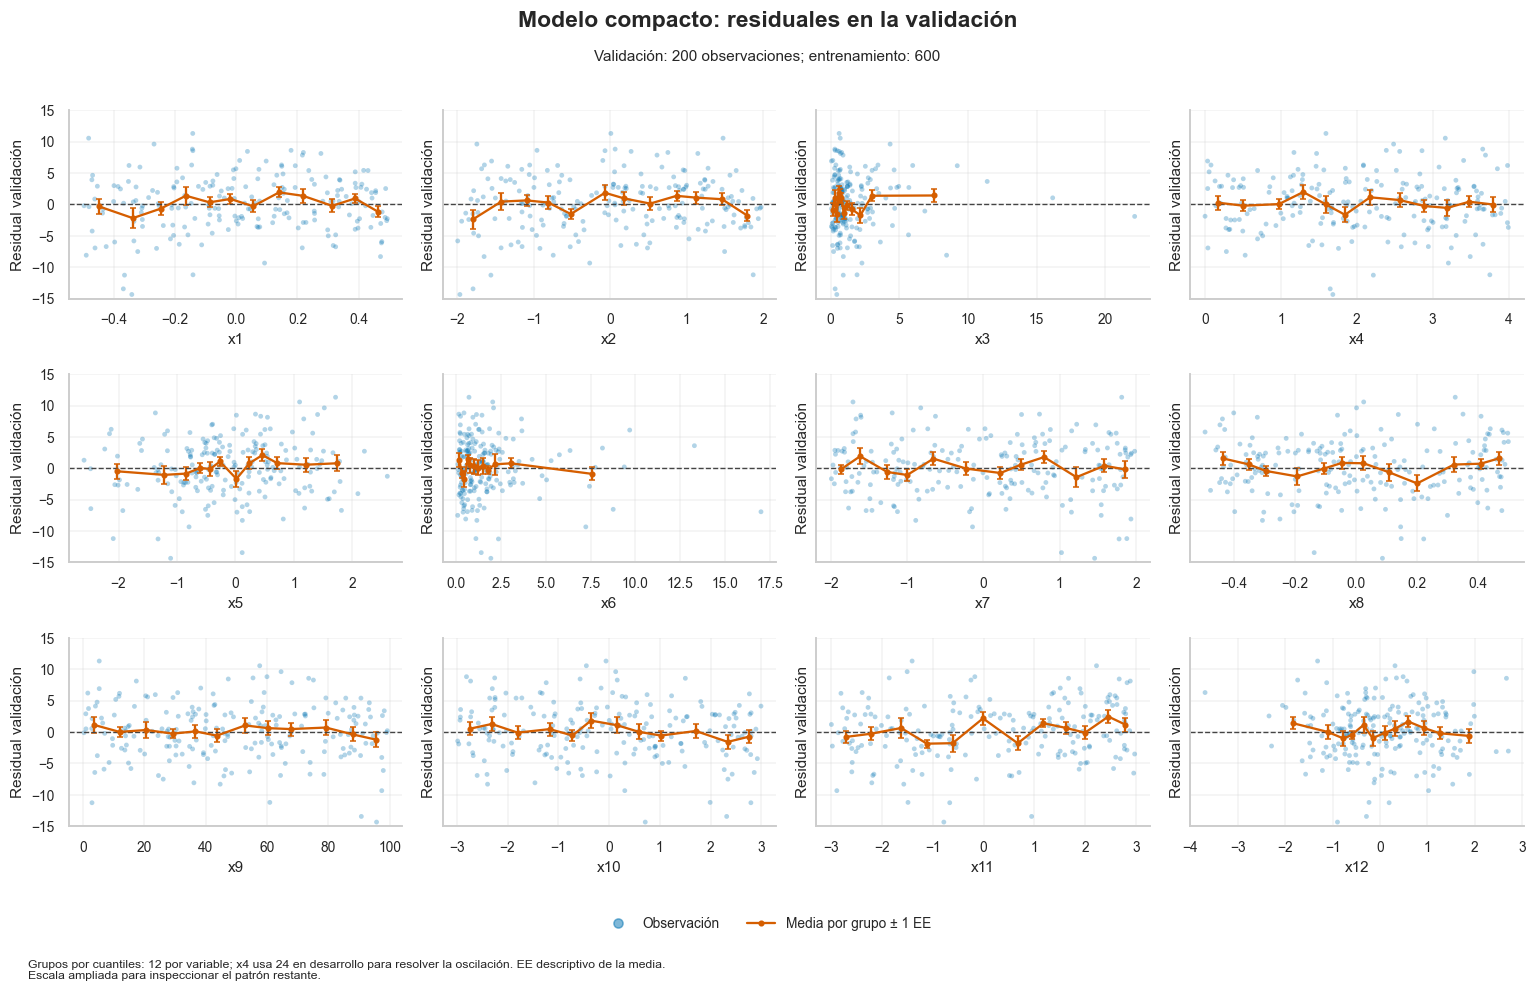

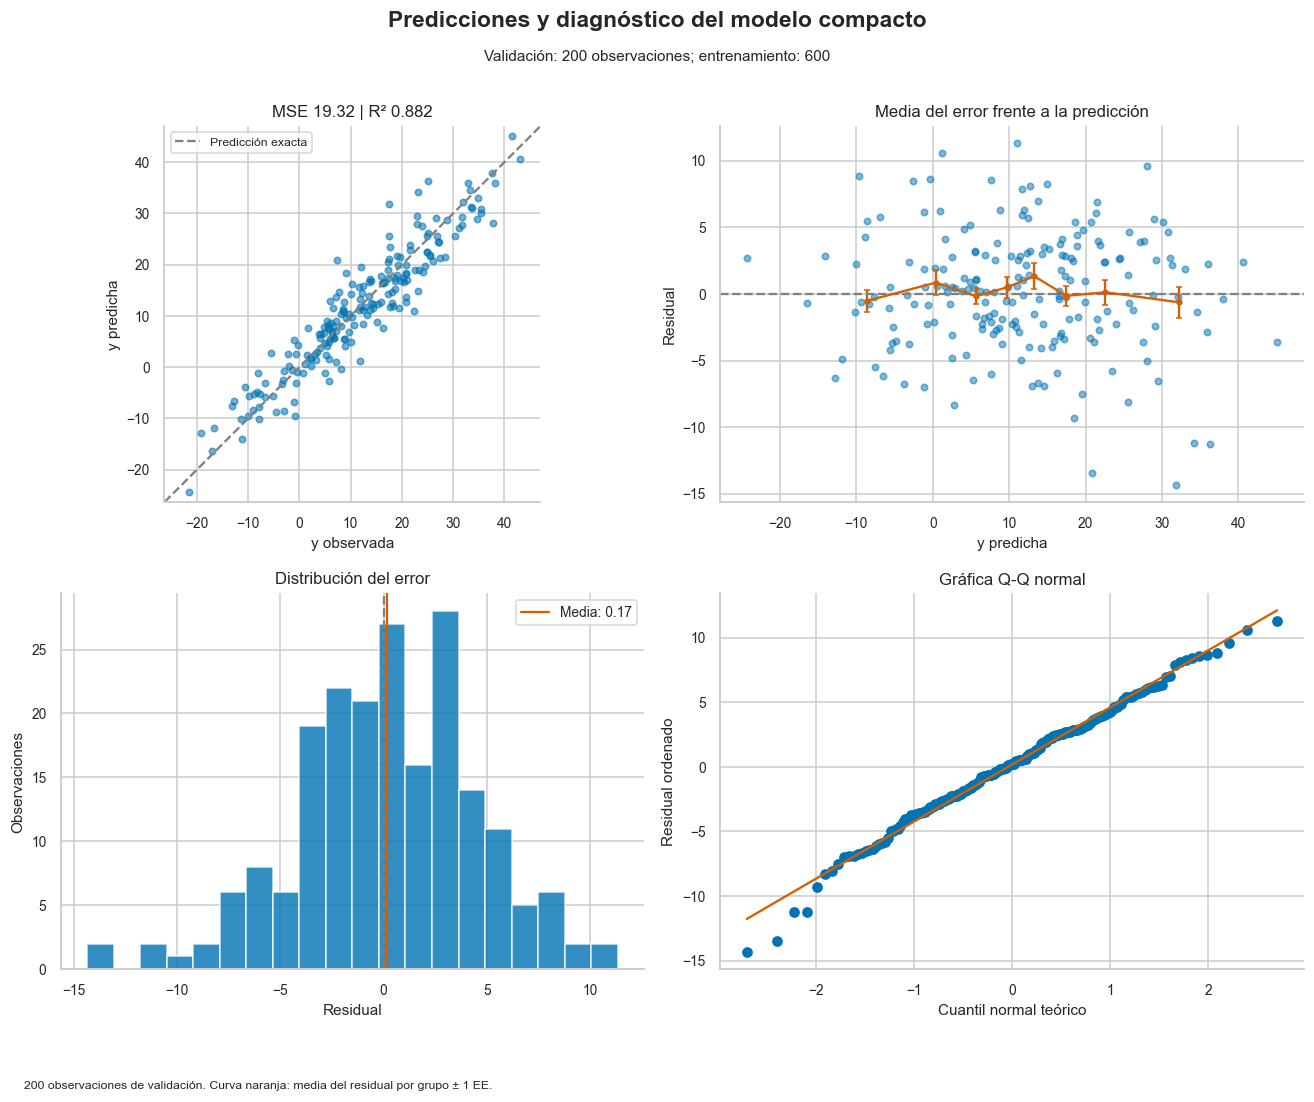

In [14]:
residual_validacion = y_val.to_numpy() - pred_validacion
paneles_respuesta(X_val, residual_validacion,
                 "Residual validación", "07_residuales_validacion.png")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes[0, 0]
ax.scatter(y_val, pred_validacion, alpha=0.55, s=18, color="#0072B2")
limites = [min(y_val.min(), pred_validacion.min()) - 2, max(y_val.max(), pred_validacion.max()) + 2]
ax.plot(limites, limites, "--", color="gray", label="Predicción exacta")
ax.set(xlim=limites, ylim=limites, xlabel="y observada", ylabel="y predicha",
       title=f"MSE {filas_validacion[1]['MSE']:.2f} | R² {filas_validacion[1]['R2']:.3f}")
ax.set_aspect("equal", adjustable="box")
ax.legend(fontsize=8)
ax = axes[0, 1]
ax.scatter(pred_validacion, residual_validacion, alpha=0.5, s=18, color="#0072B2")
tendencia_por_grupos(ax, pred_validacion, residual_validacion, grupos=8)
ax.axhline(0, color="gray", linestyle="--")
ax.set(xlabel="y predicha", ylabel="Residual", title="Media del error frente a la predicción")
ax = axes[1, 0]
ax.hist(residual_validacion, bins=20, color="#0072B2", alpha=0.8)
ax.axvline(0, color="gray", linestyle="--")
ax.axvline(residual_validacion.mean(), color="#D55E00", label=f"Media: {residual_validacion.mean():.2f}")
ax.set(xlabel="Residual", ylabel="Observaciones", title="Distribución del error")
ax.legend(fontsize=9)
stats.probplot(residual_validacion, dist="norm", plot=axes[1, 1])
axes[1, 1].set(xlabel="Cuantil normal teórico", ylabel="Residual ordenado", title="Gráfica Q-Q normal")
guardar_figura("08_validacion.png",
               nota="200 observaciones de validación. Curva naranja: media del residual por grupo ± 1 EE.")

## Predicciones de entrega

La especificación elegida se ajusta de nuevo con las 800 observaciones de `train.csv`.
Se generan 400 predicciones en el orden original de `test.csv` y se guardan en
`entregas/tarea-01/v2e419aae/predicciones.csv`, con una sola columna llamada `y`.
Las métricas de validación anteriores corresponden al ajuste con 600 observaciones.


In [15]:
test = pd.read_csv(MIS_DATOS / "test.csv")
assert test.shape == (400, 12)
assert list(test.columns) == VARIABLES
assert np.isfinite(test.to_numpy()).all()

matriz_final = construye_final(train)
modelo_final = LinearRegression().fit(matriz_final, train["y"])
predicciones = modelo_final.predict(construye_final(test))
assert predicciones.shape == (400,)
assert np.isfinite(predicciones).all()
assert modelo_final.rank_ == matriz_final.shape[1], "La matriz final tiene colinealidad exacta."

destino = RAIZ / "entregas/tarea-01" / CARPETA / "predicciones.csv"
destino.parent.mkdir(parents=True, exist_ok=True)
# Escribir primero un temporal evita dejar una entrega truncada si falla la escritura.
temporal = destino.with_suffix(".csv.tmp")
pd.DataFrame({"y": predicciones}).to_csv(temporal, index=False)
temporal.replace(destino)
entrega = pd.read_csv(destino)
assert entrega.shape == (400, 1) and list(entrega.columns) == ["y"]
assert np.allclose(entrega["y"], predicciones, rtol=1e-12, atol=1e-12)

coeficientes = pd.DataFrame({
    "termino": ["intercepto", *matriz_final.columns],
    "coeficiente": [modelo_final.intercept_, *modelo_final.coef_],
})
coeficientes.to_csv(RESULTADOS / "coeficientes.csv", index=False)
display(coeficientes)
metricas = {
    "clave": CLAVE_UNICA, "variante": CARPETA,
    "estimador": "sklearn.linear_model.LinearRegression", "columnas": list(matriz_final),
    "filas_desarrollo": 600, "filas_validacion": 200, "filas_ajuste_final": 800,
    "cv_desarrollo": {"baseline": cv_baseline, "compacto": evaluar_cv(construye_final(X_train)), "lasso": cv_lasso},
    "lasso": {"alpha": float(ajuste_lasso.alpha_), "columnas_candidatas": 454,
              "coeficientes_no_nulos": no_cero_lasso, "MSE_validacion": mse_lasso_validacion,
              "iteraciones": int(ajuste_lasso.n_iter_), "dual_gap": float(ajuste_lasso.dual_gap_)},
    "seleccion_en_desarrollo": preferido_cv,
    "versiones": {"python": platform.python_version(), "numpy": np.__version__,
                  "pandas": pd.__version__, "scikit_learn": sklearn.__version__},
    "sha256_datos": {nombre: hashlib.sha256((MIS_DATOS / f"{nombre}.csv").read_bytes()).hexdigest()
                     for nombre in ["train", "test"]},
    "sha256_predicciones": hashlib.sha256(destino.read_bytes()).hexdigest(),
    "validacion": filas_validacion, "reduccion_mse_validacion": mejora,
    "intervalo_bootstrap_mse_95": intervalo.tolist(),
    "predicciones": len(predicciones),
    "MSE_meta_oficial": None,
    "validacion_reutilizada": True,
    "seleccion_guiada_adaptativa": True,
    "codigo_notebook_sha256": hashlib.sha256("\n\n".join(
        "".join(c["source"]) for c in json.loads((RAIZ / "tareas/tarea_01_aproximacion_funcion.ipynb")
        .read_text(encoding="utf-8"))["cells"] if c["cell_type"] == "code").encode()).hexdigest(),
}
(RESULTADOS / "metricas.json").write_text(json.dumps(metricas, indent=2, ensure_ascii=False), encoding="utf-8")
manifiesto_figuras = []
for archivo in sorted(RESULTADOS.glob("*.png")):
    with Image.open(archivo) as imagen:
        manifiesto_figuras.append({"archivo": archivo.name, "ancho": imagen.width,
                                  "alto": imagen.height,
                                  "sha256": hashlib.sha256(archivo.read_bytes()).hexdigest()})
(RESULTADOS / "figuras_manifest.json").write_text(
    json.dumps(manifiesto_figuras, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Predicciones: {destino.relative_to(RAIZ)}")
print(f"{len(predicciones)} predicciones; rango [{predicciones.min():.2f}, {predicciones.max():.2f}]")


,termino,coeficiente
0,intercepto,3.1128
1,x11,1.6814
2,x2_cuadrado,3.8343
3,seno_x4,7.2461
4,log_x6,3.2075
5,x7_cubo,2.2316
6,escalon_x9,9.3365
7,interaccion_x1_x11,10.2702


Predicciones: entregas\tarea-01\v2e419aae\predicciones.csv
400 predicciones; rango [-26.39, 44.25]


## Referencias

- Scikit-learn: [mínimos cuadrados ordinarios](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares).
- Scikit-learn: [generación de variables polinomiales](https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features).
- Scikit-learn: [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html).

Las instrucciones para ejecutar el notebook están en [INICIO_208999.md](INICIO_208999.md).
